<a id="table-of-contents"></a>

# Table of Contents

1. [1. מבוא לפרויקט](#1-project-intro)
2. [2. דרישות הפרויקט](#2-project-requirements)
   1. [2.1 בחירת פרמטרים למחקר](#21-parameter-selection)
   2. [2.2 Ablation Study](#22-ablation-study)
   3. [2.3 מדדי תהליך ההתכנסות](#23-convergence-metrics)
   4. [2.4 מדדי איכות הביצוע](#24-performance-metrics)
   5. [2.5 מדדים פנימיים של הרשת](#25-internal-network-metrics)
3. [3. בחירת כיוון המחקר והנמקה](#3-research-direction-and-motivation)
   1. [3.1 Dataset שנבחר](#31-selected-dataset)
   2. [3.2 ארכיטקטורת הרשת שנבחרה](#32-selected-network-architecture)
   3. [3.3 הגדרות בסיס קבועות](#33-fixed-baseline-settings)
   4. [3.4 פרמטרים שנבחרו ל-Ablation](#34-selected-ablation-parameters)
   5. [3.5 Ablation ראשון: Learning Rate](#35-first-ablation-learning-rate)
   6. [3.6 Ablation שני: Optimizer](#36-second-ablation-optimizer)
   7. [3.7 Ablation שלישי: Batch Size](#37-third-ablation-batch-size)
   8. [3.8 מדדים שנבחן](#38-evaluated-metrics)
   9. [3.9 נימוק כללי לבחירה](#39-general-justification)
   10. [3.10 שאלת המחקר](#310-research-question)
4. [4. מבנה הניסויים](#4-experiment-structure)
   1. [4.1 מודל בסיס](#41-baseline-model)
   2. [4.2 קבוצת ניסויים 1 - Learning Rate](#42-learning-rate-group)
   3. [4.3 קבוצת ניסויים 2 - Optimizer](#43-optimizer-group)
   4. [4.4 קבוצת ניסויים 3 - Batch Size](#44-batch-size-group)
   5. [4.5 עקרונות ההשוואה](#45-comparison-principles)
5. [5. סביבת עבודה וייבוא ספריות](#5-environment-and-imports)
6. [6. טעינת הנתונים והכנתם](#6-data-loading-and-preparation)
7. [7. מודל הבסיס](#7-baseline-model)
   1. [7.1 הגדרת מודל ה-CNN](#71-cnn-model-definition)
   2. [7.2 ויזואליזציה של ארכיטקטורת המודל](#72-cnn-architecture-visualization)
8. [8. Pipeline של ניסוי אימון](#8-training-experiment-pipeline)
   1. [8.1 מעקב אחר שינויי משקלים](#81-weight-change-tracking)
   2. [8.2 חישוב מדדי ביצוע חיצוניים](#82-external-performance-metrics)
   3. [8.3 פונקציות עזר לגרפים](#83-plotting-helpers)
   4. [8.4 פונקציית הרצת ניסוי](#84-run-experiment-function)
9. [9. הרצת מודל הבסיס וניתוחו](#9-baseline-experiment-and-analysis)
10. [10. הרצת ניסויי ה-Ablation](#10-ablation-experiments)
11. [11. ויזואליזציה והשוואת תוצאות](#11-results-visualization-and-comparison)
    1. [11.1 השוואת מדדי ביצוע](#111-performance-comparison)
    2. [11.2 השוואת התכנסות](#112-convergence-comparison)
12. [12. ניתוח מדדים פנימיים של הרשת](#12-internal-network-analysis)
    1. [12.1 סיכום שינויי משקלים](#121-weight-change-summary)
    2. [12.2 הקשת התנודתית ביותר](#122-most-volatile-weight)
    3. [12.3 הופעות חוזרות ב-Top 3](#123-repeated-top3-analysis)
13. [13. דיון](#13-discussion)
14. [14. מסקנות](#14-conclusions)

---

<a id="1-project-intro"></a>

# 1. מבוא ללמידה עמוקה – פרויקט

## Afeka College of Engineering

### Semester B, 2026

**סטודנטים:**
- אביעד צפרי – 322281452
- דוד אזימוב – 205697592

---

<a id="2-project-requirements"></a>

<div dir="rtl" style="text-align: right;">

# 2. פרויקט גמר — Deep Learning

במסגרת פרויקט הגמר יש לכתוב **מיני-מאמר מחקרי** בשפה העברית, הכולל ויזואליזציה של התוצאות, דיון ומסקנות מעמיקות.

* באישור ד"ר שרון ניתן לכתוב גם באנגלית

העבודה תתבצע בצוותים של זוגות או שלשות. במסגרת המחקר יש לבצע **Ablation Study** של רשתות נוירונים, במטרה להבין את הדינמיקה הפנימית של הרשתות.

הרעיון המרכזי הוא לבחון קונפיגורציות שונות של תהליך האימון, ולנתח הן את מדדי הביצוע החיצוניים של המודל והן מדדים פנימיים המתארים את תהליך ההתכנסות של הרשת.

<a id="21-parameter-selection"></a>
## 2.1 בחירת פרמטרים למחקר

על מנת להגדיר את המחקר, יש לבחור פריט אחד או יותר מכל אחת מהקטגוריות הבאות:

<a id="211-dataset"></a>
### 2.1.1 Dataset

- MNIST
- CIFAR-10
- Fashion-MNIST

<a id="212-network-depth"></a>
### 2.1.2 ארכיטקטורת הרשת — מספר שכבות חבויות

- 2 שכבות
- 4 שכבות
- 8 שכבות
- 16 שכבות

<a id="213-layer-configuration"></a>
### 2.1.3 קונפיגורציה של שכבה

יש לבחור את מספר הנוירונים / Filters / MaxPool Layers בכל שכבה.

<a id="214-activation-function"></a>
### 2.1.4 Activation Function

- ReLU
- Sigmoid
- Tanh
- Softmax
- Leaky ReLU

<a id="215-loss-function"></a>
### 2.1.5 Loss Function

- Cross Entropy

<a id="216-optimizer"></a>
### 2.1.6 Optimizer

- Adam
- SGD
- SGD + Momentum
- RMSprop

<a id="217-learning-rate"></a>
### 2.1.7 Learning Rate

- 0.1
- 0.05
- 0.01
- 0.001

<a id="218-batch-size"></a>
### 2.1.8 Batch Size

- 1
- 16
- 32
- 64
- 128

<a id="219-data-split"></a>
### 2.1.9 יחס חלוקה בין Training / Validation / Test

- 90 / 0 / 10
- 80 / 0 / 20
- 80 / 10 / 10
- 70 / 0 / 30
- 70 / 10 / 20

<a id="2110-imbalance-level"></a>
### 2.1.10 מידת חוסר איזון הנתונים

- 50 / 50
- 40 / 60
- 30 / 70
- 20 / 80
- 10 / 90

---

<a id="22-ablation-study"></a>
## 2.2 Ablation Study

יש לבצע Ablation של **שלושה** מתוך הפרמטרים הבאים, לפי בחירתכם:

- Dataset
- ארכיטקטורת רשת — מספר שכבות חבויות
- ארכיטקטורת רשת — מספר נוירונים בכל שכבה
- Activation Function
- Loss Function
- Optimizer
- Learning Rate
- Batch Size
- גודל הדאטה: Training / Validation / Test
- מידת חוסר איזון הנתונים בדאטסט

<a id="23-convergence-metrics"></a>
## 2.3 מדדי תהליך ההתכנסות

במסגרת המחקר יש לבחון את המדדים הבאים של תהליך ההתכנסות:

- Loss
- Number of iterations until convergence

<a id="24-performance-metrics"></a>
## 2.4 מדדי איכות הביצוע

יש לבחון את מדדי הביצוע הבאים:

- TP / FP / TN / FN
- Accuracy
- Precision
- Recall
- Specificity
- F1 Score
- ROC-AUC

<a id="25-internal-network-metrics"></a>
## 2.5 מדדים פנימיים של הרשת

בנוסף למדדים החיצוניים, יש לבחון מדדים פנימיים המתארים את השינויים במשקלי הרשת במהלך האימון:

- ממוצע שינוי ערכי הקשתות בכל שכבה + ערך אבסולוטי
- סכום שינוי ערכי הקשתות בכל שכבה + ערך אבסולוטי
- חציון שינוי ערכי הקשתות בכל שכבה + ערך אבסולוטי
- הקשת הכי תנודתית
- Top 3 הקשתות התנודתיות ביותר + ממוצע
- בדיקה האם קיימת קשת שבכל איטרציה נמצאת ב־Top 3

</div>

---

<a id="3-research-direction-and-motivation"></a>

<div dir="rtl" style="text-align: right;">

# 3. בחירת כיוון המחקר והנמקה

בפרויקט זה נבצע מחקר מסוג **Ablation Study** על רשת נוירונים, במטרה לבדוק כיצד שינויים בפרמטרים מרכזיים בתהליך האימון משפיעים על ביצועי המודל, על קצב ההתכנסות, ועל הדינמיקה הפנימית של שינויי המשקלים ברשת.

בהתאם לדרישות הפרויקט, נדרש לבחור מספר רכיבים מתוך רשימת אפשרויות הכוללת Dataset, ארכיטקטורה, פונקציות אקטיבציה, Optimizer, Learning Rate, Batch Size, חלוקת הנתונים ומידת חוסר איזון הנתונים. בנוסף, יש לבצע Ablation של שלושה פרמטרים, ולבחון מדדי ביצוע חיצוניים לצד מדדים פנימיים של הרשת.

<a id="31-selected-dataset"></a>
## 3.1 Dataset שנבחר

ה־Dataset שנבחר הוא:

**Fashion-MNIST**

מתוך Fashion-MNIST נבצע בעיית **סיווג בינארית** בין שתי מחלקות:

**T-shirt/top vs Shirt**

הבחירה ב־Fashion-MNIST נעשתה משום שהוא Dataset מורכב ומעניין יותר מ־MNIST רגיל, אך עדיין פשוט ונוח יותר לעבודה מאשר CIFAR-10. בניגוד ל־MNIST, שבו הסיווג של ספרות בכתב יד נחשב לרוב קל יחסית, Fashion-MNIST כולל תמונות של פריטי לבוש, ולכן הוא מאפשר לבחון את יכולת המודל ללמוד הבחנות ויזואליות פחות טריוויאליות.

הבחירה בשתי מחלקות דומות יחסית, T-shirt/top ו־Shirt, הופכת את המשימה למעניינת יותר, משום שההבדל בין המחלקות אינו חד וברור כמו בין מחלקות שונות מאוד. בנוסף, סיווג בינארי מאפשר לחשב ולהציג בצורה ברורה את כל מדדי הביצוע הנדרשים, כגון:

* TP / FP / TN / FN
* Accuracy
* Precision
* Recall
* Specificity
* F1 Score
* ROC-AUC

<a id="32-selected-network-architecture"></a>
## 3.2 ארכיטקטורת הרשת שנבחרה

נשתמש ברשת CNN קטנה וקבועה לאורך כל הניסויים:

```text
Input: 28x28x1

Conv2D, 32 filters, 3x3
ReLU
MaxPooling2D, 2x2

Conv2D, 64 filters, 3x3
ReLU
MaxPooling2D, 2x2

Flatten

Dense, 64 neurons
ReLU

Dense, 1 neuron
Sigmoid
```

הבחירה ב־CNN מתאימה משום שמדובר בנתוני תמונה. שכבות קונבולוציה מאפשרות לרשת ללמוד תבניות מקומיות בתמונה, כגון קצוות, אזורים, מרקמים וצורות בסיסיות. בנוסף, שימוש ב־MaxPooling מקטין את ממדי המידע ומסייע לרשת להתמקד בתבניות חשובות יותר.

הארכיטקטורה שנבחרה אינה פשוטה מדי, ולכן היא מתאימה למחקר על רשתות נוירונים, אך גם אינה גדולה או מסובכת מדי. כך ניתן לבצע ניסויים רבים יחסית בזמן סביר, מבלי להפוך את העבודה לעמוסה או קשה מדי לניתוח.

<a id="33-fixed-baseline-settings"></a>
## 3.3 הגדרות בסיס קבועות

כדי שההשוואה בין הניסויים תהיה הוגנת, נגדיר מודל בסיס ונשנה בכל פעם רק פרמטר אחד.

הגדרות הבסיס הן:

| רכיב                     | בחירה                                  |
| ------------------------ | -------------------------------------- |
| Dataset                  | Fashion-MNIST                          |
| משימה                    | סיווג בינארי: T-shirt/top vs Shirt     |
| ארכיטקטורה               | CNN עם שתי שכבות Conv ושכבת Dense אחת  |
| Activation hidden layers | ReLU                                   |
| Output activation        | Sigmoid                                |
| Loss function            | Binary Cross Entropy                   |
| Optimizer בסיסי          | Adam                                   |
| Learning Rate בסיסי      | 0.001                                  |
| Batch Size בסיסי         | 64                                     |
| חלוקת נתונים             | 80% Training, 10% Validation, 10% Test |
| איזון מחלקות             | 50 / 50                                |
| Early Stopping           | לפי Validation Loss                    |

<a id="34-selected-ablation-parameters"></a>
## 3.4 פרמטרים שנבחרו ל־Ablation

במסגרת העבודה נבצע Ablation על שלושה פרמטרים מרכזיים:

1. **Learning Rate**
2. **Optimizer**
3. **Batch Size**

הבחירה בשלושת הפרמטרים האלה נעשתה משום שהם משפיעים ישירות על תהליך האימון, על קצב ההתכנסות, על יציבות הלמידה, ועל איכות המודל הסופי.

<a id="35-first-ablation-learning-rate"></a>
## 3.5 Ablation ראשון: Learning Rate

נבדוק מספר ערכים שונים של Learning Rate, לדוגמה:

```text
0.1
0.01
0.001
```

ה־Learning Rate הוא אחד הפרמטרים החשובים ביותר בתהליך האימון. ערך גבוה מדי עלול לגרום לתהליך למידה לא יציב, תנודות ב־Loss או אפילו חוסר התכנסות. לעומת זאת, ערך נמוך מדי עלול לגרום להתכנסות איטית מאוד.

לכן, Ablation על Learning Rate מאפשר לבדוק כיצד גודל הצעד בעדכון המשקלים משפיע על:

* קצב הירידה של ה־Loss
* יציבות תהליך האימון
* מספר האיטרציות עד התכנסות
* איכות הסיווג הסופית

<a id="36-second-ablation-optimizer"></a>
## 3.6 Ablation שני: Optimizer

נבדוק מספר Optimizers שונים:

```text
SGD
SGD + Momentum
RMSprop
Adam
```

ה־Optimizer קובע כיצד מתבצע עדכון המשקלים של הרשת בכל שלב באימון. Optimizers שונים משתמשים במנגנונים שונים לעדכון המשקלים, ולכן הם עשויים להשפיע בצורה משמעותית על מהירות ההתכנסות ועל איכות הפתרון הסופי.

השוואה בין Optimizers תאפשר לבדוק, למשל, האם Adam מתכנס מהר יותר מ־SGD, האם Momentum משפר את SGD, והאם RMSprop נותן התכנסות יציבה יותר.

<a id="37-third-ablation-batch-size"></a>
## 3.7 Ablation שלישי: Batch Size

נבדוק מספר ערכים של Batch Size:

```text
16
32
64
128
```

Batch Size משפיע על אופי עדכון המשקלים. Batch קטן יוצר עדכונים תכופים ורועשים יותר, ולעיתים יכול לעזור להכללה טובה יותר. לעומת זאת, Batch גדול יותר יוצר עדכונים יציבים יותר, אך ייתכן שיגרום להתכנסות פחות גמישה.

לכן, Ablation על Batch Size מאפשר לבחון כיצד גודל קבוצת האימון בכל צעד משפיע על:

* תנודתיות ה־Loss
* קצב ההתכנסות
* ביצועי המודל על קבוצת הבדיקה
* גודל ותדירות שינויי המשקלים ברשת

<a id="38-evaluated-metrics"></a>
## 3.8 מדדים שנבחן

בכל ניסוי נבחן שלושה סוגים של מדדים.

<a id="381-convergence-metrics"></a>
### 3.8.1 מדדי התכנסות

* Loss לאורך האימון
* Validation Loss לאורך האימון
* מספר Epochs עד התכנסות
* ה־Epoch שבו התקבל ה־Validation Loss הטוב ביותר

<a id="382-external-performance-metrics"></a>
### 3.8.2 מדדי ביצוע חיצוניים

* Confusion Matrix
* TP / FP / TN / FN
* Accuracy
* Precision
* Recall
* Specificity
* F1 Score
* ROC-AUC

<a id="383-internal-network-metrics"></a>
### 3.8.3 מדדים פנימיים של הרשת

בנוסף למדדי הביצוע הרגילים, נבחן גם מדדים פנימיים המתארים את שינויי המשקלים ברשת במהלך האימון:

* ממוצע שינוי המשקלים בכל שכבה
* ממוצע שינוי המשקלים בערך מוחלט בכל שכבה
* סכום שינויי המשקלים בערך מוחלט בכל שכבה
* חציון שינויי המשקלים בערך מוחלט בכל שכבה
* המשקל התנודתי ביותר
* שלושת המשקלים התנודתיים ביותר
* בדיקה האם קיימים משקלים שמופיעים שוב ושוב בין המשקלים התנודתיים ביותר

מדדים אלו מאפשרים לא רק לבדוק האם המודל הצליח לסווג נכון, אלא גם להבין מה קרה בתוך הרשת במהלך תהליך הלמידה.

<a id="39-general-justification"></a>
## 3.9 נימוק כללי לבחירה

הבחירה ב־Fashion-MNIST, ברשת CNN קטנה, וב־Ablation על Learning Rate, Optimizer ו־Batch Size יוצרת מחקר מאוזן: מצד אחד, העבודה מספיק עשירה כדי לכלול ניתוח ביצועים, גרפים, טבלאות ומדדים פנימיים; מצד שני, היא אינה גדולה או מסובכת מדי.

גישה זו מאפשרת להתמקד בניתוח איכותי של תהליך האימון, במקום להריץ כמות גדולה מדי של ניסויים שקשה להסביר. לכן, הבחירה מתאימה למיני־מאמר מחקרי ברור, מסודר ומעמיק.

<a id="310-research-question"></a>
## 3.10 שאלת המחקר

שאלת המחקר המרכזית בעבודה היא:

**כיצד פרמטרים מרכזיים בתהליך האימון — Learning Rate, Optimizer ו־Batch Size — משפיעים על איכות הסיווג, קצב ההתכנסות והדינמיקה הפנימית של שינויי המשקלים ברשת CNN עבור בעיית סיווג בינארית ב־Fashion-MNIST?**

</div>

---

<a id="4-experiment-structure"></a>

<div dir="rtl" style="text-align: right;">

# 4. מבנה הניסויים

לאחר שהוגדרו הדאטסט, הארכיטקטורה ופרמטרי ה־Ablation, נגדיר כעת את פרוטוקול הניסוי. מטרת שלב זה היא להבטיח שההשוואה בין הניסויים תהיה עקבית והוגנת.

בכל הניסויים נשתמש באותה ארכיטקטורת CNN ובאותה חלוקת נתונים. בכל פעם נשנה פרמטר אחד בלבד, בעוד ששאר ההגדרות יישארו קבועות. גישה זו מאפשרת לבודד את ההשפעה של כל פרמטר על ביצועי המודל, על קצב ההתכנסות, ועל שינויי המשקלים הפנימיים ברשת.

<a id="41-baseline-model"></a>
## 4.1 מודל בסיס

מודל הבסיס ישמש כנקודת ייחוס להשוואה מול שאר הניסויים.

| רכיב                | ערך בסיס                            |
| ------------------- | ----------------------------------- |
| Optimizer           | Adam                                |
| Learning Rate       | 0.001                               |
| Batch Size          | 64                                  |
| Loss Function       | Binary Cross Entropy                |
| Activation Function | ReLU                                |
| Output Activation   | Sigmoid                             |
| Data Split          | 80% Train, 10% Validation, 10% Test |
| Class Balance       | 50 / 50                             |

<a id="42-learning-rate-group"></a>
## 4.2 קבוצת ניסויים 1 — Learning Rate

בקבוצת ניסויים זו נשנה רק את ערך ה־Learning Rate.

| Experiment | Optimizer | Learning Rate | Batch Size |
| ---------- | --------- | ------------- | ---------- |
| LR-1       | Adam      | 0.1           | 64         |
| LR-2       | Adam      | 0.01          | 64         |
| LR-3       | Adam      | 0.001         | 64         |

<a id="43-optimizer-group"></a>
## 4.3 קבוצת ניסויים 2 — Optimizer

בקבוצת ניסויים זו נשנה רק את סוג ה־Optimizer.

| Experiment | Optimizer      | Learning Rate | Batch Size |
| ---------- | -------------- | ------------- | ---------- |
| OPT-1      | SGD            | 0.001         | 64         |
| OPT-2      | SGD + Momentum | 0.001         | 64         |
| OPT-3      | RMSprop        | 0.001         | 64         |
| OPT-4      | Adam           | 0.001         | 64         |

<a id="44-batch-size-group"></a>
## 4.4 קבוצת ניסויים 3 — Batch Size

בקבוצת ניסויים זו נשנה רק את גודל ה־Batch.

| Experiment | Optimizer | Learning Rate | Batch Size |
| ---------- | --------- | ------------- | ---------- |
| BS-1       | Adam      | 0.001         | 16         |
| BS-2       | Adam      | 0.001         | 32         |
| BS-3       | Adam      | 0.001         | 64         |
| BS-4       | Adam      | 0.001         | 128        |

<a id="45-comparison-principles"></a>
## 4.5 עקרונות ההשוואה

כדי לשמור על ניסוי מבוקר, כל ניסוי יורץ עם אותו seed, אותה חלוקת נתונים, אותה ארכיטקטורה ואותו מספר מקסימלי של epochs. בנוסף, נשתמש ב־Early Stopping לפי Validation Loss, כך שנוכל להשוות לא רק את איכות המודל הסופי, אלא גם את מהירות ויציבות ההתכנסות.

עבור כל ניסוי נשמור את המדדים הבאים:

* מדדי ביצוע חיצוניים: Accuracy, Precision, Recall, Specificity, F1 Score, ROC-AUC ו־Confusion Matrix.
* מדדי התכנסות: Training Loss, Validation Loss, מספר epochs עד עצירה, וה־epoch שבו התקבל ה־Validation Loss הטוב ביותר.
* מדדים פנימיים: שינויי משקלים בכל שכבה לאורך האימון, כולל ממוצע, סכום, חציון, ערכים מוחלטים, והמשקלים התנודתיים ביותר.

</div>

---

<a id="5-environment-and-imports"></a>

<div dir="rtl" style="text-align: right;">

# 5. סביבת עבודה וייבוא ספריות

בשלב זה נגדיר את סביבת העבודה, נייבא את הספריות הדרושות, ונקבע seed קבוע לצורך שחזור תוצאות הניסויים.

הספריות המרכזיות שבהן נשתמש הן:

- `TensorFlow / Keras` לבניית ואימון רשת ה־CNN.
- `NumPy` ו־`Pandas` לעיבוד נתונים ושמירת תוצאות.
- `Matplotlib` ליצירת גרפים וויזואליזציות.
- `Scikit-learn` לחלוקת הנתונים ולחישוב מדדי הביצוע.

</div>

In [ ]:
# Install required packages
import sys

!{sys.executable} -m pip install tensorflow scikit-learn pandas matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


<div dir="rtl" style="text-align: right;">

<a id="6-data-loading-and-preparation"></a>
# 6. טעינת הנתונים והכנתם

בשלב זה נטען את Dataset מסוג Fashion-MNIST מתוך Keras. מתוך כלל המחלקות בדאטסט נבחר שתי מחלקות בלבד:

* **T-shirt/top**
* **Shirt**

שתי מחלקות אלו נבחרו משום שהן דומות יחסית מבחינה ויזואלית, ולכן הסיווג ביניהן מאתגר יותר מאשר סיווג בין מחלקות שונות מאוד. בנוסף, נבצע איזון בין המחלקות כך שכל מחלקה תופיע באותה כמות דוגמאות. בצורה זו נוכל לוודא שמדדי הביצוע אינם מושפעים מחוסר איזון מלאכותי בין המחלקות.

לאחר מכן נחלק את הנתונים לשלוש קבוצות:

* **Training set** — משמש לאימון המודל.
* **Validation set** — משמש למעקב אחרי ביצועי המודל בזמן האימון ול־Early Stopping.
* **Test set** — משמש להערכת הביצועים הסופיים של המודל לאחר סיום האימון.

יחס החלוקה שנבחר הוא:

**80% Training, 10% Validation, 10% Test**

</div>

In [33]:
# Load Fashion-MNIST
(X_train_full, y_train_full), (X_test_original, y_test_original) = keras.datasets.fashion_mnist.load_data()

# Combine original train and test sets.
# We will create our own 80/10/10 split.
X_all = np.concatenate([X_train_full, X_test_original], axis=0)
y_all = np.concatenate([y_train_full, y_test_original], axis=0)

# Fashion-MNIST labels:
# 0 = T-shirt/top
# 6 = Shirt
CLASS_0 = 0
CLASS_1 = 6

class_names = {
    0: "T-shirt/top",
    1: "Shirt"
}

# Keep only the two selected classes
mask = (y_all == CLASS_0) | (y_all == CLASS_1)

X_binary = X_all[mask]
y_binary_original = y_all[mask]

# Convert labels:
# T-shirt/top -> 0
# Shirt       -> 1
y_binary = np.where(y_binary_original == CLASS_0, 0, 1)

print("Original binary dataset size:", X_binary.shape)
print("Class distribution before balancing:")
print(pd.Series(y_binary).value_counts().rename(index=class_names))

Original binary dataset size: (14000, 28, 28)
Class distribution before balancing:
T-shirt/top    7000
Shirt          7000
Name: count, dtype: int64


In [34]:
# Separate samples by class
X_class_0 = X_binary[y_binary == 0]
y_class_0 = y_binary[y_binary == 0]

X_class_1 = X_binary[y_binary == 1]
y_class_1 = y_binary[y_binary == 1]

# Balance the classes by taking the same number of samples from each class
n_samples_per_class = min(len(X_class_0), len(X_class_1))

rng = np.random.default_rng(SEED)

idx_class_0 = rng.choice(len(X_class_0), size=n_samples_per_class, replace=False)
idx_class_1 = rng.choice(len(X_class_1), size=n_samples_per_class, replace=False)

X_balanced = np.concatenate([X_class_0[idx_class_0], X_class_1[idx_class_1]], axis=0)
y_balanced = np.concatenate([y_class_0[idx_class_0], y_class_1[idx_class_1]], axis=0)

# Shuffle balanced dataset
shuffle_idx = rng.permutation(len(X_balanced))

X_balanced = X_balanced[shuffle_idx]
y_balanced = y_balanced[shuffle_idx]

print("Balanced dataset size:", X_balanced.shape)
print("Class distribution after balancing:")
print(pd.Series(y_balanced).value_counts().rename(index=class_names))

Balanced dataset size: (14000, 28, 28)
Class distribution after balancing:
Shirt          7000
T-shirt/top    7000
Name: count, dtype: int64


In [35]:
# Normalize pixel values to [0, 1]
X_balanced = X_balanced.astype("float32") / 255.0

# Add channel dimension for CNN: (samples, height, width, channels)
X_balanced = np.expand_dims(X_balanced, axis=-1)

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=SEED,
    stratify=y_balanced
)

# Second split: temporary 20% -> 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts().rename(index=class_names))

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().rename(index=class_names))

print("\nTest distribution:")
print(pd.Series(y_test).value_counts().rename(index=class_names))

Train shape: (11200, 28, 28, 1)
Validation shape: (1400, 28, 28, 1)
Test shape: (1400, 28, 28, 1)

Train distribution:
T-shirt/top    5600
Shirt          5600
Name: count, dtype: int64

Validation distribution:
T-shirt/top    700
Shirt          700
Name: count, dtype: int64

Test distribution:
Shirt          700
T-shirt/top    700
Name: count, dtype: int64


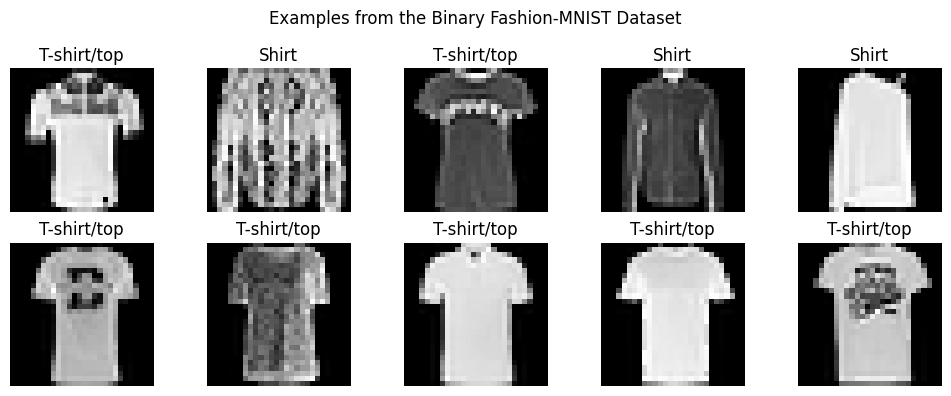

In [36]:
# Visualize some examples from the binary Fashion-MNIST dataset
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.suptitle("Examples from the Binary Fashion-MNIST Dataset")
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

<a id="7-baseline-model"></a>
# 7. מודל הבסיס

לפני ביצוע ניסויי ה־Ablation, נגדיר מודל בסיס שישמש כנקודת ייחוס לכל ההשוואות. בכל הניסויים נשתמש באותה ארכיטקטורת רשת, ונשנה בכל פעם רק פרמטר אימון אחד: Learning Rate, Optimizer או Batch Size.

מודל הבסיס הוא רשת CNN קטנה המותאמת לנתוני תמונה בגודל `28x28x1`. הרשת כוללת שתי שכבות קונבולוציה, שתי שכבות MaxPooling, שכבת Dense חבויה אחת, ושכבת פלט בינארית.

מבנה הרשת:

```text
Input: 28x28x1

Conv2D, 32 filters, 3x3
ReLU
MaxPooling2D, 2x2

Conv2D, 64 filters, 3x3
ReLU
MaxPooling2D, 2x2

Flatten

Dense, 64 neurons
ReLU

Dense, 1 neuron
Sigmoid
```

שכבות הקונבולוציה נועדו ללמוד תבניות מקומיות בתמונה, כגון קצוות, אזורים וצורות בסיסיות. שכבות ה־MaxPooling מקטינות את ממדי המידע ומסייעות לרשת להתמקד בתבניות המרכזיות. שכבת ה־Dense מבצעת שילוב של המאפיינים שנלמדו, ושכבת הפלט מחזירה הסתברות להשתייכות למחלקה החיובית.

מכיוון שמדובר בבעיית סיווג בינארית, פונקציית הפלט היא `Sigmoid`, ופונקציית ההפסד היא `Binary Cross Entropy`.

</div>

In [37]:
# Create optimizer function
def create_optimizer(optimizer_name, learning_rate):
    """
    Create optimizer according to experiment configuration.
    """
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "sgd":
        return keras.optimizers.SGD(learning_rate=learning_rate)

    elif optimizer_name in ["sgd_momentum", "sgd + momentum", "sgd+momentum"]:
        return keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)

    elif optimizer_name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)

    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

<a id="71-cnn-model-definition"></a>

<div dir="rtl" style="text-align: right;">

## 7.1 הגדרת מודל ה־CNN

בשלב זה נגדיר את פונקציות העזר לבניית המודל. תחילה נגדיר פונקציה ליצירת ה־Optimizer לפי שם ו־Learning Rate, ולאחר מכן נגדיר פונקציה שבונה ומקמפלת את רשת ה־CNN.

</div>

In [38]:
# Build CNN model function
def build_cnn_model(
    optimizer_name="adam",
    learning_rate=0.001,
    input_shape=(28, 28, 1)
):
    """
    Build and compile the baseline CNN model.
    """

    tf.keras.backend.clear_session()

    model = keras.Sequential(
        [
            layers.Input(shape=input_shape, name="input_image"),

            layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                name="conv_1"
            ),
            layers.MaxPooling2D(
                pool_size=(2, 2),
                name="max_pool_1"
            ),

            layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                name="conv_2"
            ),
            layers.MaxPooling2D(
                pool_size=(2, 2),
                name="max_pool_2"
            ),

            layers.Flatten(name="flatten"),

            layers.Dense(
                units=64,
                activation="relu",
                name="dense_hidden"
            ),

            layers.Dense(
                units=1,
                activation="sigmoid",
                name="output"
            )
        ],
        name="baseline_fashion_mnist_cnn"
    )

    optimizer = create_optimizer(
        optimizer_name=optimizer_name,
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc")
        ]
    )

    return model

In [39]:
# Build and compile the baseline CNN model
baseline_model = build_cnn_model(
    optimizer_name="adam",
    learning_rate=0.001,
    input_shape=(28, 28, 1)
)

baseline_model.summary()

Model: "baseline_fashion_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,345 (474.00 KB)

 Trainable params: 121,345 (474.00 KB)

 Non-trainable params: 0 (0.00 B)

<a id="72-cnn-architecture-visualization"></a>

<div dir="rtl" style="text-align: right;">

## 7.2 ויזואליזציה של ארכיטקטורת המודל

לאחר הגדרת מודל הבסיס, נציג ויזואליזציה סכמטית של ארכיטקטורת ה־CNN. התרשים מציג את זרימת המידע ברשת: החל מתמונת הקלט, דרך שכבות הקונבולוציה וה־Pooling, ועד לשכבת ה־Flatten, שכבת ה־Dense ושכבת הפלט הבינארית.

מספר הבלוקים המוצגים בשכבות הקונבולוציה וה־Pooling הוא להמחשה בלבד, ואינו מייצג אחד־לאחד את מספר ה־filters בפועל. שכבת הפלט כוללת נוירון יחיד עם פונקציית `Sigmoid`, משום שמדובר בבעיית סיווג בינארית.

</div>

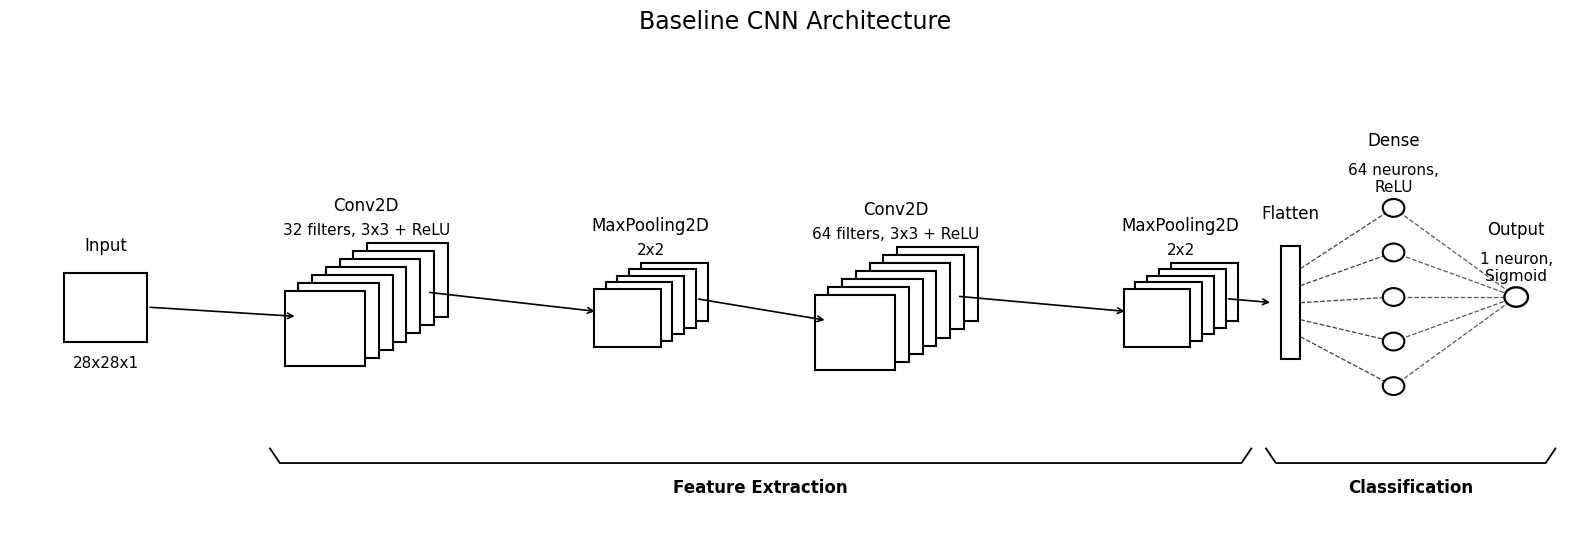

In [40]:
# Visualize the CNN architecture
def draw_input_block(ax, x, y, w=0.9, h=0.9):
    rect = Rectangle((x, y), w, h, facecolor="white", edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)

    ax.text(x + w / 2, y + h + 0.22, "Input", ha="center", va="bottom", fontsize=12)
    ax.text(x + w / 2, y - 0.18, "28x28x1", ha="center", va="top", fontsize=11)

    return {
        "left": (x, y + h / 2),
        "right": (x + w, y + h / 2),
        "x": x,
        "y": y,
        "w": w,
        "h": h
    }


def draw_stack(ax, x, y, w, h, depth, dx, dy, title, subtitle):
    """
    Draw a stack of opaque feature maps.
    The blocks are filled white so you do not 'see through' them.
    """
    # draw from back to front
    for i in range(depth - 1, -1, -1):
        rect = Rectangle(
            (x + i * dx, y + i * dy),
            w,
            h,
            facecolor="white",
            edgecolor="black",
            linewidth=1.5
        )
        ax.add_patch(rect)

    stack_center_x = x + (w + dx * (depth - 1)) / 2
    top_y = y + h + dy * (depth - 1)

    ax.text(stack_center_x, top_y + 0.34, title, ha="center", va="bottom", fontsize=12)
    ax.text(stack_center_x, top_y + 0.06, subtitle, ha="center", va="bottom", fontsize=11)

    # connector points from the visual middle of the whole stack
    left_anchor = (x + dx * (depth // 2) * 0.5, y + h / 2 + dy * (depth // 2) * 0.5)
    right_anchor = (
        x + w + dx * (depth - 1) - dx * (depth // 2) * 0.5,
        y + h / 2 + dy * (depth - 1) - dy * (depth // 2) * 0.5
    )

    front_x = x + dx * (depth - 1)
    front_y = y + dy * (depth - 1)

    front_points = [
        (front_x + w, front_y + h * 0.20),
        (front_x + w, front_y + h * 0.50),
        (front_x + w, front_y + h * 0.80),
    ]

    return {
        "left": left_anchor,
        "right": right_anchor,
        "front_points": front_points,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "depth": depth,
        "dx": dx,
        "dy": dy
    }


def draw_flatten_block(ax, x, y, w=0.38, h=1.15):
    rect = Rectangle((x, y), w, h, facecolor="white", edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)

    ax.text(x + w / 2, y + h + 0.28, "Flatten", ha="center", va="bottom", fontsize=12)

    points = [
        (x + w, y + h * 0.20),
        (x + w, y + h * 0.35),
        (x + w, y + h * 0.50),
        (x + w, y + h * 0.65),
        (x + w, y + h * 0.80),
    ]

    return {
        "left": (x, y + h / 2),
        "right": (x + w, y + h / 2),
        "front_points": points,
        "x": x,
        "y": y,
        "w": w,
        "h": h
    }


def draw_dense_column(ax, x, y_center, n_nodes=5, spacing=0.55, r=0.11):
    centers = []
    total_h = (n_nodes - 1) * spacing
    y0 = y_center - total_h / 2

    for i in range(n_nodes):
        cy = y0 + i * spacing
        circ = Circle((x, cy), r, facecolor="white", edgecolor="black", linewidth=1.5, zorder=3)
        ax.add_patch(circ)
        centers.append((x, cy))

    # Slightly larger spacing to avoid overlap with multiline text
    ax.text(x, y0 + total_h + 0.72, "Dense", ha="center", va="bottom", fontsize=12)
    ax.text(x, y0 + total_h + 0.16, "64 neurons,\nReLU", ha="center", va="bottom", fontsize=11)

    return centers


def draw_output_node(ax, x, y, r=0.12):
    circ = Circle((x, y), r, facecolor="white", edgecolor="black", linewidth=1.7, zorder=3)
    ax.add_patch(circ)

    # Slightly larger spacing to avoid overlap with multiline text
    ax.text(x, y + 0.72, "Output", ha="center", va="bottom", fontsize=12)
    ax.text(x, y + 0.16, "1 neuron,\nSigmoid", ha="center", va="bottom", fontsize=11)

    return (x, y)


def arrow(ax, p1, p2, lw=1.2):
    ax.annotate(
        "",
        xy=p2,
        xytext=p1,
        arrowprops=dict(arrowstyle="->", linewidth=lw, color="black")
    )


def dashed(ax, p1, p2, lw=0.95, alpha=0.7):
    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        linestyle="--",
        linewidth=lw,
        color="black",
        alpha=alpha
    )


def bracket(ax, x0, x1, y, text):
    ax.plot([x0, x0 + 0.10, x1 - 0.10, x1], [y + 0.18, y, y, y + 0.18],
            linewidth=1.3, color="black")
    ax.text((x0 + x1) / 2, y - 0.20, text, ha="center", va="top",
            fontsize=12, fontweight="bold")


def plot_cnn_architecture():
    fig, ax = plt.subplots(figsize=(16, 5.6))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 6)
    ax.axis("off")

    # Blocks
    input_block = draw_input_block(ax, 0.55, 2.45, w=0.85, h=0.85)

    conv1 = draw_stack(
        ax,
        x=2.8, y=2.15,
        w=0.82, h=0.92,
        depth=7, dx=0.14, dy=0.10,
        title="Conv2D",
        subtitle="32 filters, 3x3 + ReLU"
    )

    pool1 = draw_stack(
        ax,
        x=5.95, y=2.38,
        w=0.68, h=0.72,
        depth=5, dx=0.12, dy=0.08,
        title="MaxPooling2D",
        subtitle="2x2"
    )

    conv2 = draw_stack(
        ax,
        x=8.2, y=2.10,
        w=0.82, h=0.92,
        depth=7, dx=0.14, dy=0.10,
        title="Conv2D",
        subtitle="64 filters, 3x3 + ReLU"
    )

    pool2 = draw_stack(
        ax,
        x=11.35, y=2.38,
        w=0.68, h=0.72,
        depth=5, dx=0.12, dy=0.08,
        title="MaxPooling2D",
        subtitle="2x2"
    )

    flatten = draw_flatten_block(ax, x=12.95, y=2.23, w=0.2, h=1.40)

    dense_nodes = draw_dense_column(ax, x=14.1, y_center=3.0, n_nodes=5, spacing=0.55, r=0.11)
    output_node = draw_output_node(ax, x=15.35, y=3.0, r=0.12)

    # Main arrows between stages
    arrow(ax, input_block["right"], (conv1["left"][0] - 0.08, conv1["left"][1]))
    arrow(ax, conv1["right"], (pool1["left"][0] - 0.08, pool1["left"][1]))
    arrow(ax, pool1["right"], (conv2["left"][0] - 0.08, conv2["left"][1]))
    arrow(ax, conv2["right"], (pool2["left"][0] - 0.08, pool2["left"][1]))
    arrow(ax, pool2["right"], (flatten["left"][0] - 0.08, flatten["left"][1]))

    # Flatten to Dense: schematic fully connected fan-out
    for src, dst in zip(flatten["front_points"], dense_nodes):
        dashed(ax, src, dst, lw=0.9, alpha=0.75)

    # Dense to Output
    for node in dense_nodes:
        dashed(ax, node, output_node, lw=0.9, alpha=0.65)

    # Brackets
    # Feature Extraction includes: Conv1, Pool1, Conv2, Pool2
    bracket(ax, 2.65, 12.65, 0.95, "Feature Extraction")

    # Classification includes: Flatten, Dense, Output
    bracket(ax, 12.80, 15.75, 0.95, "Classification")

    plt.title("Baseline CNN Architecture", fontsize=17, pad=18)
    plt.tight_layout()
    plt.show()


plot_cnn_architecture()

<a id="8-training-experiment-pipeline"></a>

<div dir="rtl" style="text-align: right;">

# 8. Pipeline של ניסוי אימון

לאחר הגדרת מודל הבסיס, נבנה כעת תהליך ניסוי אחיד שישמש עבור כל הרצות ה־Ablation. בכל ניסוי נבנה מודל חדש מאפס, נאמן אותו על אותם נתוני אימון, נעקוב אחר תהליך ההתכנסות, ונחשב מדדי ביצוע על קבוצת הבדיקה.

בנוסף למדדי הביצוע החיצוניים, נעקוב גם אחר שינויי המשקלים הפנימיים ברשת לאורך האימון. מטרת מדדים אלו היא להבין לא רק האם המודל מצליח לסווג נכון, אלא גם כיצד הרשת משתנה במהלך תהליך הלמידה.

בכל epoch נשמור עבור כל שכבה trainable את המדדים הבאים:

- ממוצע שינוי המשקלים.
- ממוצע שינוי המשקלים בערך מוחלט.
- סכום שינויי המשקלים בערך מוחלט.
- חציון שינויי המשקלים בערך מוחלט.
- שינוי המשקל הגדול ביותר באותו epoch.
- שלושת המשקלים בעלי השינוי הגדול ביותר.

במחקר זה נמדוד את שינויי המשקלים ברמת epoch. כלומר, בכל epoch נשווה את ערכי המשקלים בסוף ה־epoch לערכים שהיו בסוף ה־epoch הקודם. מדידה זו מאפשרת לבחון את הדינמיקה הפנימית של הרשת לאורך תהליך האימון בצורה יציבה וברורה.

</div>

<a id="81-weight-change-tracking"></a>

<div dir="rtl" style="text-align: right;">

## 8.1 מעקב אחר שינויי משקלים

כדי למדוד את הדינמיקה הפנימית של הרשת, נגדיר callback ייעודי שעוקב אחר שינויי המשקלים בסוף כל epoch. המדידה מתבצעת עבור משקלי `kernel` בלבד, כלומר עבור הקשתות המחברות בין יחידות החישוב, ולא עבור ערכי bias.

</div>

In [41]:
class WeightChangeTracker(keras.callbacks.Callback):
    """
    Track internal weight changes after each epoch.

    The tracker compares the trainable kernel weights at the end of each epoch
    to their values at the previous epoch.
    """

    def __init__(self):
        super().__init__()
        self.previous_weights = {}
        self.layer_stats = []
        self.top_weight_changes = []

    def _get_kernel_weights(self):
        """
        Extract only kernel weights from trainable layers.
        Bias terms are not included because the assignment refers to edges/weights.
        """
        kernel_weights = {}

        for layer in self.model.layers:
            for weight in layer.trainable_weights:
                weight_name = weight.name.lower()

                if "kernel" in weight_name:
                    key = f"{layer.name}/kernel"
                    kernel_weights[key] = weight.numpy().copy()

        return kernel_weights

    def on_train_begin(self, logs=None):
        self.previous_weights = self._get_kernel_weights()

    def on_epoch_end(self, epoch, logs=None):
        current_weights = self._get_kernel_weights()

        for layer_key, current_w in current_weights.items():
            previous_w = self.previous_weights[layer_key]

            delta = current_w - previous_w
            abs_delta = np.abs(delta)

            flat_abs_delta = abs_delta.flatten()

            mean_delta = np.mean(delta)
            mean_abs_delta = np.mean(abs_delta)
            sum_abs_delta = np.sum(abs_delta)
            median_abs_delta = np.median(abs_delta)
            max_abs_delta = np.max(abs_delta)

            self.layer_stats.append({
                "epoch": epoch + 1,
                "layer": layer_key,
                "mean_delta": mean_delta,
                "mean_abs_delta": mean_abs_delta,
                "sum_abs_delta": sum_abs_delta,
                "median_abs_delta": median_abs_delta,
                "max_abs_delta": max_abs_delta
            })

            # Top 3 most changed weights in this layer for this epoch
            top_k = min(3, flat_abs_delta.size)
            top_indices_flat = np.argsort(flat_abs_delta)[-top_k:][::-1]

            for rank, flat_index in enumerate(top_indices_flat, start=1):
                multi_index = np.unravel_index(flat_index, abs_delta.shape)

                self.top_weight_changes.append({
                    "epoch": epoch + 1,
                    "layer": layer_key,
                    "rank": rank,
                    "weight_index": multi_index,
                    "abs_delta": abs_delta[multi_index],
                    "delta": delta[multi_index]
                })

        self.previous_weights = current_weights

    def get_layer_stats_df(self):
        return pd.DataFrame(self.layer_stats)

    def get_top_weight_changes_df(self):
        return pd.DataFrame(self.top_weight_changes)

<div dir="rtl" style="text-align: right;">

<a id="82-external-performance-metrics"></a>

## 8.2 חישוב מדדי ביצוע חיצוניים

לאחר אימון כל מודל נחשב את מדדי הביצוע על קבוצת הבדיקה. מכיוון שמדובר בבעיית סיווג בינארית, נשתמש בסף החלטה של `0.5`: אם הסתברות הפלט גדולה או שווה ל־`0.5`, התמונה תסווג למחלקה החיובית; אחרת היא תסווג למחלקה השלילית.

המדדים שיחושבו הם:

- `TP` — מספר הדוגמאות החיוביות שסווגו כחיוביות.
- `FP` — מספר הדוגמאות השליליות שסווגו כחיוביות.
- `TN` — מספר הדוגמאות השליליות שסווגו כשליליות.
- `FN` — מספר הדוגמאות החיוביות שסווגו כשליליות.
- `Accuracy`
- `Precision`
- `Recall`
- `Specificity`
- `F1 Score`
- `ROC-AUC`

מדדים אלו יאפשרו להעריך את איכות הסיווג הסופית של כל קונפיגורציה, ולהשוות בין ניסויי ה־Ablation השונים.

</div>

In [42]:
def calculate_classification_metrics(model, X_test, y_test, threshold=0.5):
    """
    Calculate binary classification metrics for a trained model.
    """

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    try:
        roc_auc = roc_auc_score(y_test, y_prob)
    except ValueError:
        roc_auc = np.nan

    metrics = {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

    return metrics, cm, y_prob, y_pred

<a id="83-plotting-helpers"></a>

<div dir="rtl" style="text-align: right;">

## 8.3 פונקציות עזר לגרפים

נגדיר פונקציות עזר ליצירת גרפי אימון, מטריצות בלבול, וגרפים של שינויי משקלים פנימיים. פונקציות אלו ישמשו גם בניתוח מודל הבסיס וגם בהשוואת ניסויי ה־Ablation.

</div>

In [43]:
def plot_training_curves(history, title="Training Curves"):
    """
    Plot training and validation loss/accuracy curves.
    """

    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if "accuracy" in history_df.columns and "val_accuracy" in history_df.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(history_df["accuracy"], label="Training Accuracy")
        plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{title} - Accuracy")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


def plot_confusion_matrix(cm, labels=("T-shirt/top", "Shirt"), title="Confusion Matrix"):
    """
    Plot a simple confusion matrix.
    """

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=30)
    plt.yticks(tick_marks, labels)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

<div dir="rtl" style="text-align: right;">

# פונקציית הרצת ניסוי

כדי לשמור על מבנה ניסוי אחיד, נבנה פונקציה אחת שמריצה ניסוי מלא מתחילתו ועד סופו. הפונקציה תקבל את שם הניסוי ואת פרמטרי האימון המרכזיים, תבנה מודל חדש, תאמן אותו, תחשב את מדדי הביצוע, ותשמור גם את מדדי שינויי המשקלים הפנימיים.

בכל ניסוי נשתמש ב־`EarlyStopping` לפי `Validation Loss`. מנגנון זה עוצר את האימון כאשר אין שיפור בביצועי ה־validation במשך מספר epochs, ומחזיר את המשקלים הטובים ביותר שנמצאו במהלך האימון.

</div>

In [44]:
def run_experiment(
    experiment_name,
    optimizer_name="adam",
    learning_rate=0.001,
    batch_size=64,
    max_epochs=30,
    patience=5,
    verbose=1
):
    """
    Run a complete training experiment:
    1. Build a fresh CNN model.
    2. Train it with EarlyStopping.
    3. Track internal weight changes.
    4. Evaluate external classification metrics on the test set.
    5. Return all relevant outputs.
    """

    print(f"\nRunning experiment: {experiment_name}")
    print("-" * 60)
    print(f"Optimizer: {optimizer_name}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Batch Size: {batch_size}")
    print(f"Max Epochs: {max_epochs}")
    print(f"Patience: {patience}")
    print("-" * 60)

    # Reset seeds for controlled comparison
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_cnn_model(
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        input_shape=(28, 28, 1)
    )

    weight_tracker = WeightChangeTracker()

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        mode="min"
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[
            weight_tracker,
            early_stopping
        ],
        verbose=verbose
    )

    metrics, cm, y_prob, y_pred = calculate_classification_metrics(
        model=model,
        X_test=X_test,
        y_test=y_test,
        threshold=0.5
    )

    history_df = pd.DataFrame(history.history)

    epochs_trained = len(history_df)
    best_epoch = int(history_df["val_loss"].idxmin() + 1)
    best_val_loss = float(history_df["val_loss"].min())
    final_train_loss = float(history_df["loss"].iloc[-1])
    final_val_loss = float(history_df["val_loss"].iloc[-1])

    convergence_info = {
        "Experiment": experiment_name,
        "Epochs_Trained": epochs_trained,
        "Best_Epoch": best_epoch,
        "Best_Val_Loss": best_val_loss,
        "Final_Train_Loss": final_train_loss,
        "Final_Val_Loss": final_val_loss
    }

    experiment_summary = {
        "Experiment": experiment_name,
        "Optimizer": optimizer_name,
        "Learning_Rate": learning_rate,
        "Batch_Size": batch_size,
        **convergence_info,
        **metrics
    }

    result = {
        "experiment_name": experiment_name,
        "model": model,
        "history": history,
        "history_df": history_df,
        "metrics": metrics,
        "confusion_matrix": cm,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "weight_layer_stats": weight_tracker.get_layer_stats_df(),
        "top_weight_changes": weight_tracker.get_top_weight_changes_df(),
        "summary": experiment_summary
    }

    print("\nExperiment completed.")
    print("Best epoch:", best_epoch)
    print("Best validation loss:", best_val_loss)
    print("Test accuracy:", metrics["Accuracy"])
    print("Test F1:", metrics["F1"])
    print("Test ROC-AUC:", metrics["ROC_AUC"])

    return result

In [45]:
baseline_result = run_experiment(
    experiment_name="BASELINE",
    optimizer_name="adam",
    learning_rate=0.001,
    batch_size=64,
    max_epochs=30,
    patience=5,
    verbose=1
)


Running experiment: BASELINE
------------------------------------------------------------
Optimizer: adam
Learning Rate: 0.001
Batch Size: 64
Max Epochs: 30
Patience: 5
------------------------------------------------------------
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8183 - loss: 0.4100 - precision: 0.8465 - recall: 0.7777 - roc_auc: 0.8924 - val_accuracy: 0.8300 - val_loss: 0.3735 - val_precision: 0.8329 - val_recall: 0.8257 - val_roc_auc: 0.9128
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8490 - loss: 0.3362 - precision: 0.8701 - recall: 0.8205 - roc_auc: 0.9289 - val_accuracy: 0.8464 - val_loss: 0.3450 - val_precision: 0.8725 - val_recall: 0.8114 - val_roc_auc: 0.9255
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8668 - loss: 0.3069 - precision: 0.8828 - recall: 0.8459 - roc_auc: 0.9411 - val_accuracy: 0.8557 - val_loss: 0.3270 - val_precision: 0.8784 - val_recall: 0.8257 - val_roc_auc: 0.9338
Epoch 4/30
175/175 

In [46]:
baseline_summary_df = pd.DataFrame([baseline_result["summary"]])
baseline_summary_df

,Experiment,Optimizer,Learning_Rate,Batch_Size,Epochs_Trained,Best_Epoch,Best_Val_Loss,Final_Train_Loss,Final_Val_Loss,TP,FP,TN,FN,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC
0,BASELINE,adam,0.001,64,13,8,0.300677,0.158546,0.326876,619,68,632,81,0.893571,0.901019,0.884286,0.902857,0.892574,0.961265


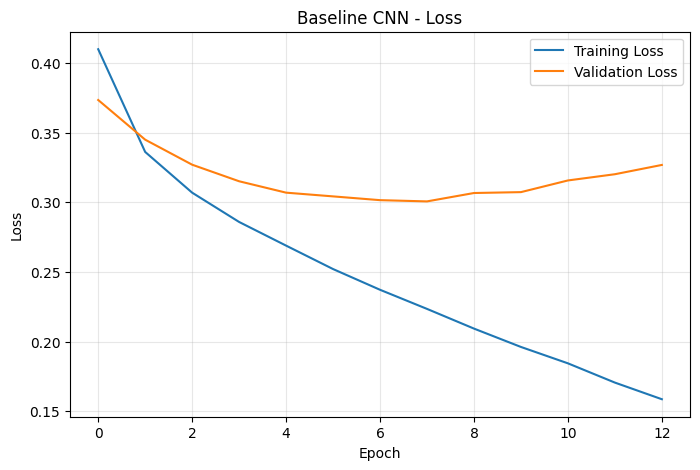

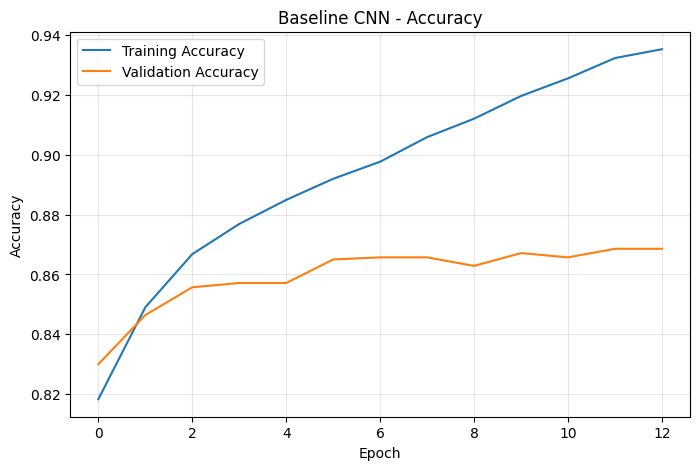

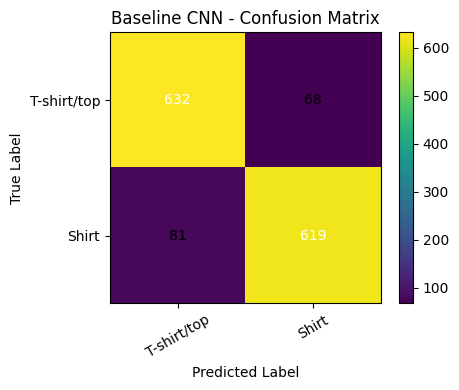

In [47]:
plot_training_curves(
    baseline_result["history"],
    title="Baseline CNN"
)

plot_confusion_matrix(
    baseline_result["confusion_matrix"],
    labels=("T-shirt/top", "Shirt"),
    title="Baseline CNN - Confusion Matrix"
)

In [48]:
baseline_weight_stats = baseline_result["weight_layer_stats"]
baseline_weight_stats.head()

,epoch,layer,mean_delta,mean_abs_delta,sum_abs_delta,median_abs_delta,max_abs_delta
0,1,conv_1/kernel,0.004915,0.018926,5.450814,0.014878,0.101003
1,1,conv_2/kernel,0.001278,0.015940,293.812927,0.011604,0.128639
2,1,dense_hidden/kernel,0.000758,0.009313,953.653015,0.005802,0.084385
3,1,output/kernel,0.002184,0.014014,0.896898,0.014025,0.030164
4,2,conv_1/kernel,-0.003132,0.011340,3.265805,0.007844,0.090799


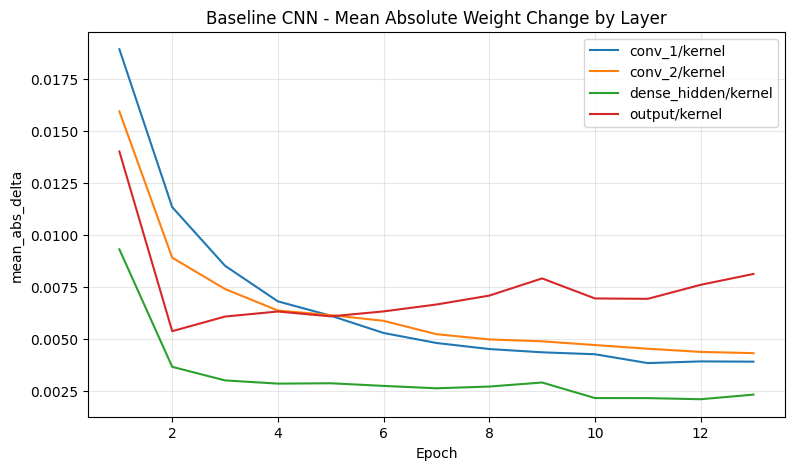

In [49]:
def plot_weight_change_by_layer(weight_stats_df, value_column="mean_abs_delta", title="Weight Change by Layer"):
    """
    Plot internal weight-change metric over epochs for each layer.
    """

    plt.figure(figsize=(9, 5))

    for layer_name in weight_stats_df["layer"].unique():
        layer_df = weight_stats_df[weight_stats_df["layer"] == layer_name]

        plt.plot(
            layer_df["epoch"],
            layer_df[value_column],
            label=layer_name
        )

    plt.xlabel("Epoch")
    plt.ylabel(value_column)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_weight_change_by_layer(
    baseline_weight_stats,
    value_column="mean_abs_delta",
    title="Baseline CNN - Mean Absolute Weight Change by Layer"
)

<div dir="rtl" style="text-align: right;">

# ניתוח תוצאות מודל הבסיס

מודל הבסיס אומן באמצעות `Adam`, עם `Learning Rate = 0.001` ו־`Batch Size = 64`. האימון נעצר לאחר 13 epochs, כאשר ה־validation loss הטוב ביותר התקבל ב־epoch מספר 8.

מתוך גרפי האימון ניתן לראות כי ה־training loss ממשיך לרדת לאורך האימון, בעוד שה־validation loss יורד בתחילת האימון אך לאחר מכן מתחיל לעלות. התנהגות זו מצביעה על תחילת תהליך של **overfitting**: המודל ממשיך להשתפר על קבוצת האימון, אך אינו משתפר באותה מידה על קבוצת ה־validation.

למרות זאת, ביצועי מודל הבסיס על קבוצת הבדיקה טובים. המודל הגיע ל־Accuracy של כ־0.894 ול־F1 Score של כ־0.893. בנוסף, ערך `ROC-AUC` של כ־0.961 מצביע על יכולת הפרדה טובה בין שתי המחלקות.

מתוך מטריצת הבלבול ניתן לראות כי המודל סיווג נכון את רוב הדוגמאות משתי המחלקות:

- `TN = 632`: דוגמאות מסוג T-shirt/top שסווגו נכון.
- `FP = 68`: דוגמאות מסוג T-shirt/top שסווגו בטעות כ־Shirt.
- `FN = 81`: דוגמאות מסוג Shirt שסווגו בטעות כ־T-shirt/top.
- `TP = 619`: דוגמאות מסוג Shirt שסווגו נכון.

הערכים של Precision ו־Recall קרובים יחסית זה לזה, ולכן ניתן להסיק שהמודל אינו מוטה בצורה חריפה לאחת המחלקות. גם ערך ה־Specificity גבוה יחסית, ולכן המודל מצליח לזהות היטב גם את המחלקה השלילית.

בנוסף למדדי הביצוע החיצוניים, נאספו גם מדדים פנימיים של שינויי המשקלים בכל epoch. ניתן לראות שכבות שונות מציגות סדרי גודל שונים של שינוי, כאשר יש להבחין בין מדדים כמו `sum_abs_delta`, המושפעים ממספר המשקלים בשכבה, לבין מדדים כמו `mean_abs_delta`, המתאימים יותר להשוואה בין שכבות בגדלים שונים.

בסך הכול, מודל הבסיס מספק נקודת ייחוס טובה להמשך ניסויי ה־Ablation. בהמשך נבדוק כיצד שינוי של `Learning Rate`, `Optimizer` ו־`Batch Size` משפיע על איכות הסיווג, על קצב ההתכנסות ועל הדינמיקה הפנימית של שינויי המשקלים.

</div>

In [50]:
experiment_configs = [
    # Learning Rate ablation
    {
        "experiment_name": "LR_0.1",
        "optimizer_name": "adam",
        "learning_rate": 0.1,
        "batch_size": 64,
        "group": "Learning Rate"
    },
    {
        "experiment_name": "LR_0.05",
        "optimizer_name": "adam",
        "learning_rate": 0.05,
        "batch_size": 64,
        "group": "Learning Rate"
    },
    {
        "experiment_name": "LR_0.01",
        "optimizer_name": "adam",
        "learning_rate": 0.01,
        "batch_size": 64,
        "group": "Learning Rate"
    },
    {
        "experiment_name": "LR_0.001",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Learning Rate"
    },

    # Optimizer ablation
    {
        "experiment_name": "OPT_SGD",
        "optimizer_name": "sgd",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Optimizer"
    },
    {
        "experiment_name": "OPT_SGD_Momentum",
        "optimizer_name": "sgd_momentum",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Optimizer"
    },
    {
        "experiment_name": "OPT_RMSprop",
        "optimizer_name": "rmsprop",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Optimizer"
    },
    {
        "experiment_name": "OPT_Adam",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Optimizer"
    },

    # Batch Size ablation
    {
        "experiment_name": "BS_16",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "group": "Batch Size"
    },
    {
        "experiment_name": "BS_32",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 32,
        "group": "Batch Size"
    },
    {
        "experiment_name": "BS_64",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "group": "Batch Size"
    },
    {
        "experiment_name": "BS_128",
        "optimizer_name": "adam",
        "learning_rate": 0.001,
        "batch_size": 128,
        "group": "Batch Size"
    },
]

In [51]:
experiment_results = {}

for config in experiment_configs:
    result = run_experiment(
        experiment_name=config["experiment_name"],
        optimizer_name=config["optimizer_name"],
        learning_rate=config["learning_rate"],
        batch_size=config["batch_size"],
        max_epochs=30,
        patience=5,
        verbose=0
    )

    result["summary"]["Group"] = config["group"]
    experiment_results[config["experiment_name"]] = result


Running experiment: LR_0.1
------------------------------------------------------------
Optimizer: adam
Learning Rate: 0.1
Batch Size: 64
Max Epochs: 30
Patience: 5
------------------------------------------------------------

Experiment completed.
Best epoch: 6
Best validation loss: 0.6932578086853027
Test accuracy: 0.5
Test F1: 0.0
Test ROC-AUC: 0.5

Running experiment: LR_0.05
------------------------------------------------------------
Optimizer: adam
Learning Rate: 0.05
Batch Size: 64
Max Epochs: 30
Patience: 5
------------------------------------------------------------

Experiment completed.
Best epoch: 1
Best validation loss: 0.6937543153762817
Test accuracy: 0.5
Test F1: 0.0
Test ROC-AUC: 0.5

Running experiment: LR_0.01
------------------------------------------------------------
Optimizer: adam
Learning Rate: 0.01
Batch Size: 64
Max Epochs: 30
Patience: 5
------------------------------------------------------------

Experiment completed.
Best epoch: 6
Best validation loss: 

In [55]:
display_columns = [
    "Group",
    "Experiment",
    "Optimizer",
    "Learning_Rate",
    "Batch_Size",
    "Epochs_Trained",
    "Best_Epoch",
    "Best_Val_Loss",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC",
    "TP",
    "FP",
    "TN",
    "FN"
]

results_summary_display = results_summary_df[display_columns].copy()

numeric_columns = [
    "Best_Val_Loss",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC"
]

results_summary_display[numeric_columns] = results_summary_display[numeric_columns].round(4)

results_summary_display

,Group,Experiment,Optimizer,Learning_Rate,Batch_Size,Epochs_Trained,Best_Epoch,Best_Val_Loss,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TP,FP,TN,FN
0,Learning Rate,LR_0.1,adam,0.100,64,11,6,0.6933,0.5000,0.0000,0.0000,1.0000,0.0000,0.5000,0,0,700,700
1,Learning Rate,LR_0.05,adam,0.050,64,6,1,0.6938,0.5000,0.0000,0.0000,1.0000,0.0000,0.5000,0,0,700,700
2,Learning Rate,LR_0.01,adam,0.010,64,11,6,0.3183,0.8729,0.8546,0.8986,0.8471,0.8760,0.9522,629,107,593,71
3,Learning Rate,LR_0.001,adam,0.001,64,13,8,0.3007,0.8936,0.9010,0.8843,0.9029,0.8926,0.9613,619,68,632,81
4,Optimizer,OPT_SGD,sgd,0.001,64,30,30,0.4653,0.8114,0.8482,0.7586,0.8643,0.8009,0.8741,531,95,605,169
5,Optimizer,OPT_SGD_Momentum,sgd_momentum,0.001,64,30,30,0.3490,0.8593,0.8547,0.8657,0.8529,0.8602,0.9389,606,103,597,94
6,Optimizer,OPT_RMSprop,rmsprop,0.001,64,18,13,0.2985,0.8850,0.9090,0.8557,0.9143,0.8815,0.9621,599,60,640,101
7,Optimizer,OPT_Adam,adam,0.001,64,13,8,0.3007,0.8936,0.9010,0.8843,0.9029,0.8926,0.9613,619,68,632,81
8,Batch Size,BS_16,adam,0.001,16,9,4,0.3060,0.8879,0.8895,0.8857,0.8900,0.8876,0.9580,620,77,623,80
9,Batch Size,BS_32,adam,0.001,32,9,4,0.3291,0.8736,0.8454,0.9143,0.8329,0.8785,0.9555,640,117,583,60


In [56]:
def plot_metric_by_group(results_df, metric, title):
    groups = results_df["Group"].unique()

    for group in groups:
        group_df = results_df[results_df["Group"] == group].copy()

        plt.figure(figsize=(8, 4.5))
        plt.bar(group_df["Experiment"], group_df[metric])

        plt.xlabel("Experiment")
        plt.ylabel(metric)
        plt.title(f"{title} - {group}")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

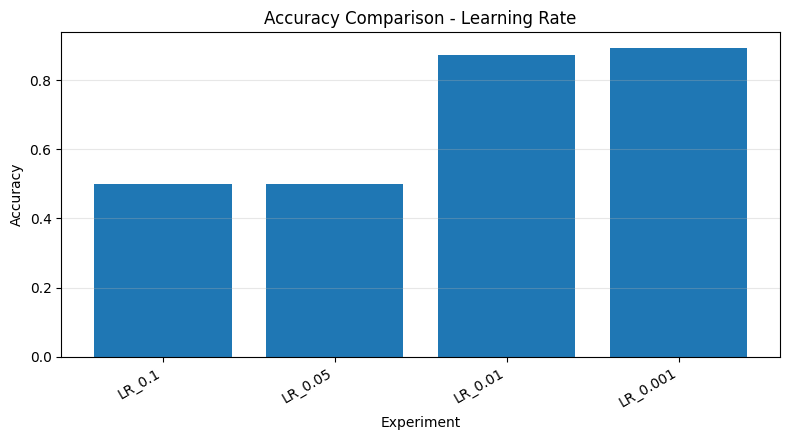

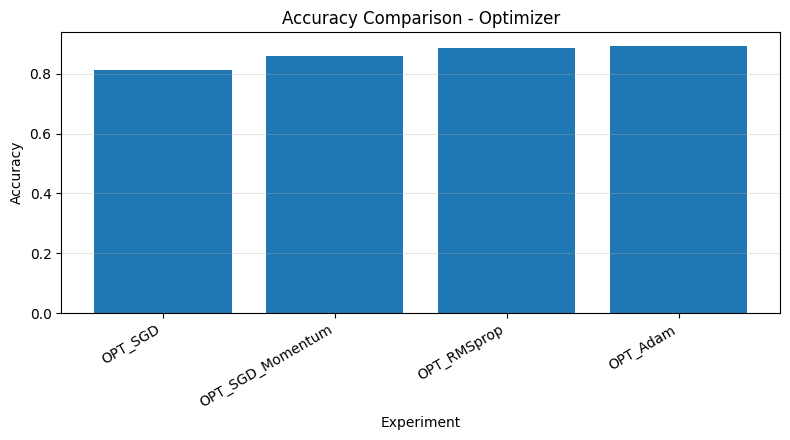

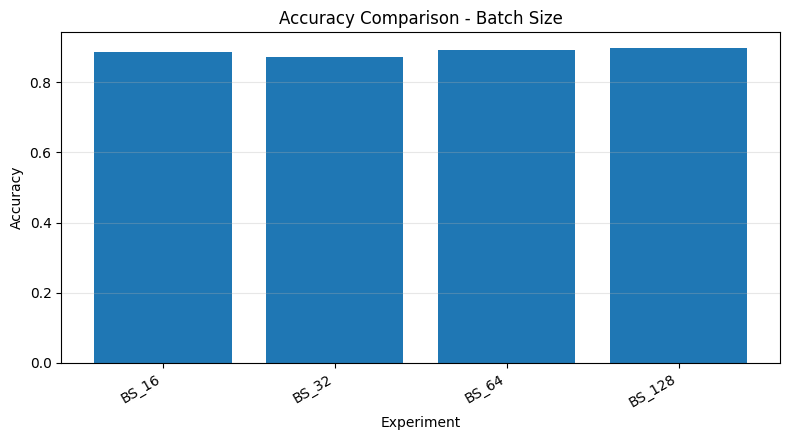

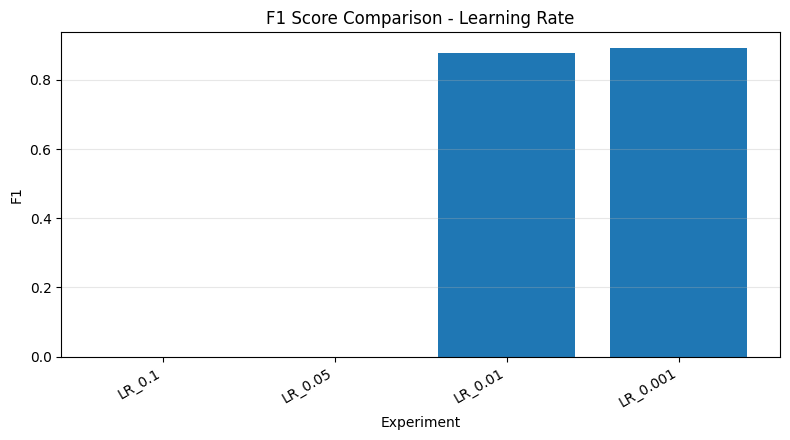

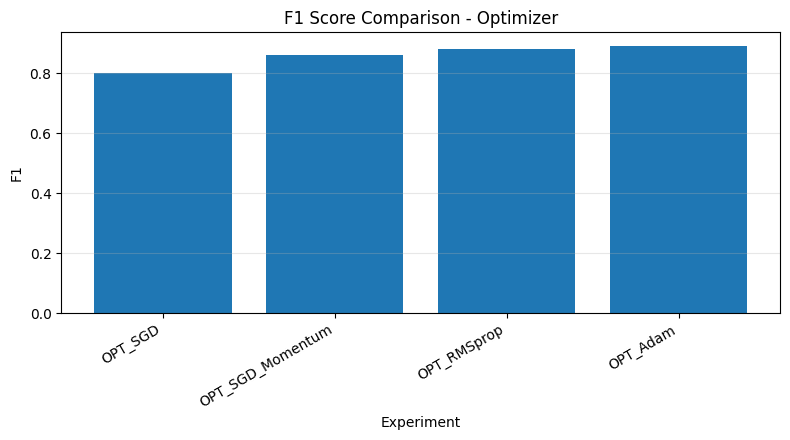

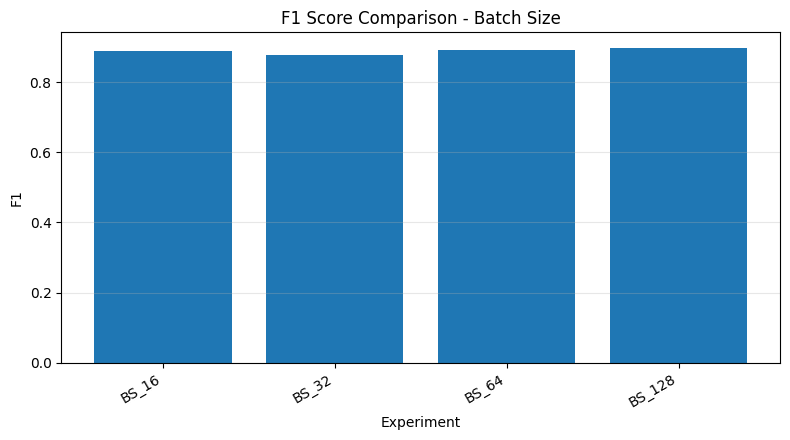

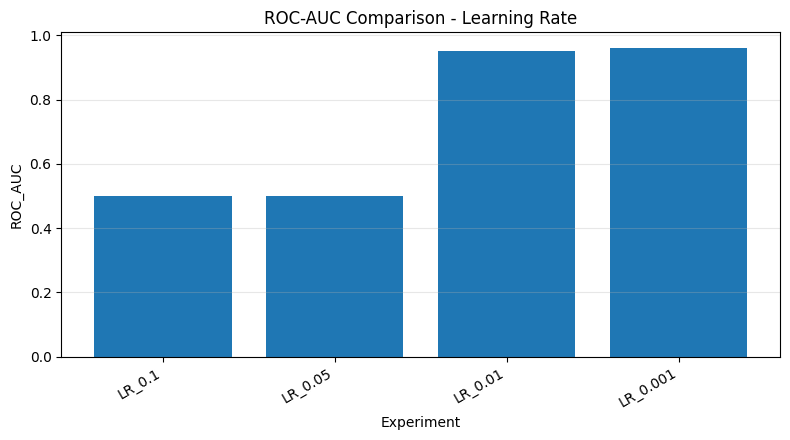

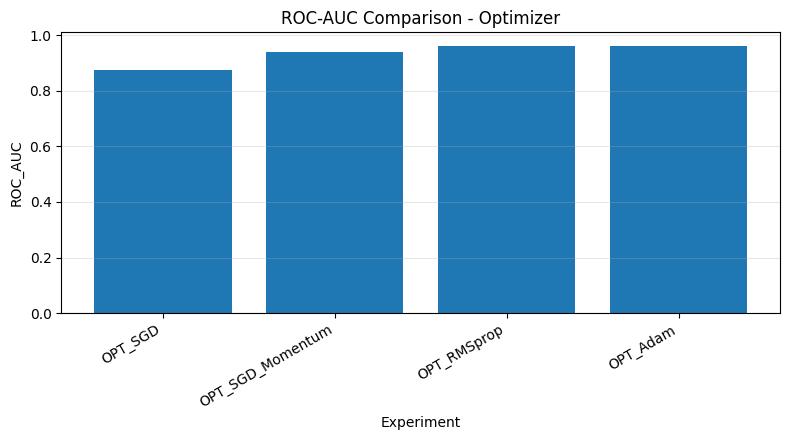

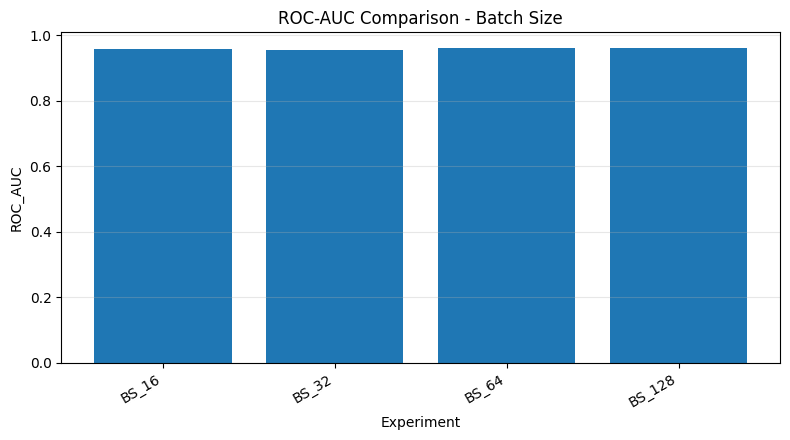

In [57]:
plot_metric_by_group(
    results_summary_df,
    metric="Accuracy",
    title="Accuracy Comparison"
)

plot_metric_by_group(
    results_summary_df,
    metric="F1",
    title="F1 Score Comparison"
)

plot_metric_by_group(
    results_summary_df,
    metric="ROC_AUC",
    title="ROC-AUC Comparison"
)

In [58]:
def plot_validation_loss_by_group(experiment_results, results_df, group_name):
    group_df = results_df[results_df["Group"] == group_name].copy()

    plt.figure(figsize=(8, 5))

    for experiment_name in group_df["Experiment"]:
        history_df = experiment_results[experiment_name]["history_df"]

        plt.plot(
            range(1, len(history_df) + 1),
            history_df["val_loss"],
            label=experiment_name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"Validation Loss Curves - {group_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

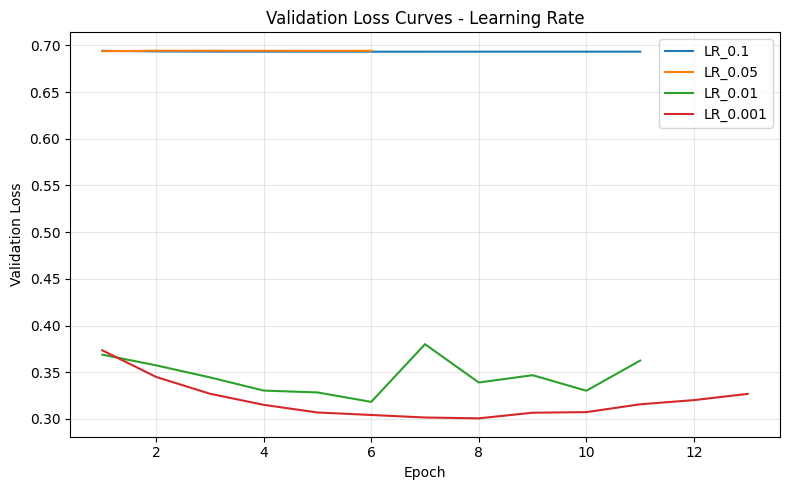

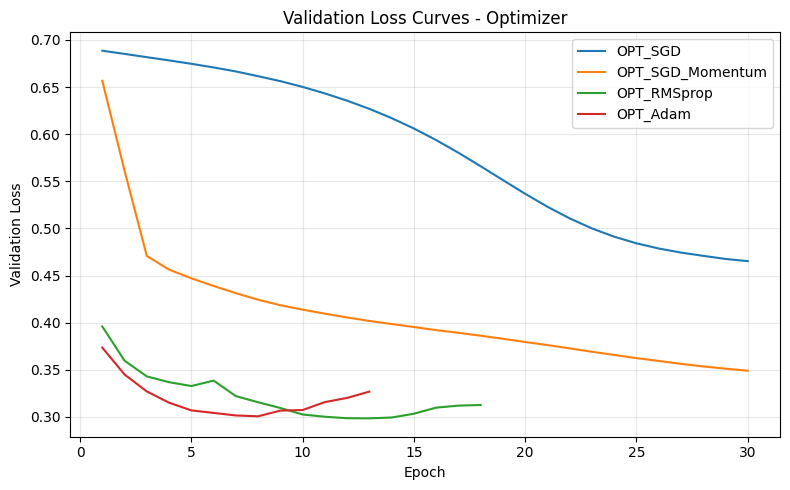

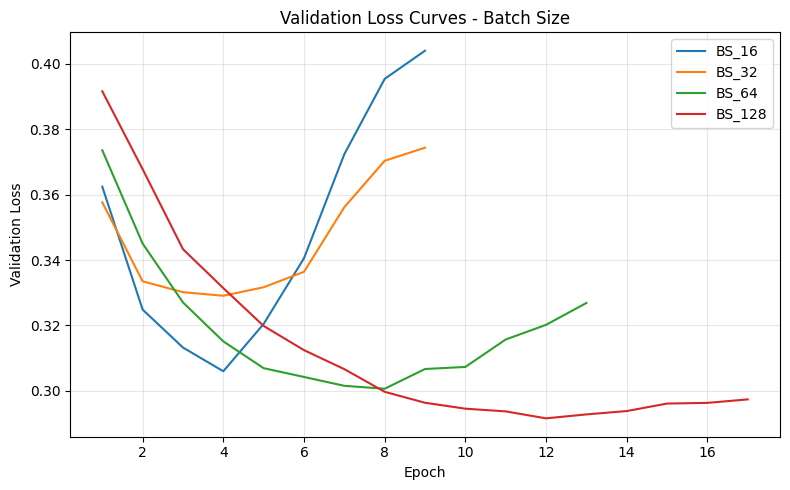

In [59]:
plot_validation_loss_by_group(
    experiment_results,
    results_summary_df,
    group_name="Learning Rate"
)

plot_validation_loss_by_group(
    experiment_results,
    results_summary_df,
    group_name="Optimizer"
)

plot_validation_loss_by_group(
    experiment_results,
    results_summary_df,
    group_name="Batch Size"
)

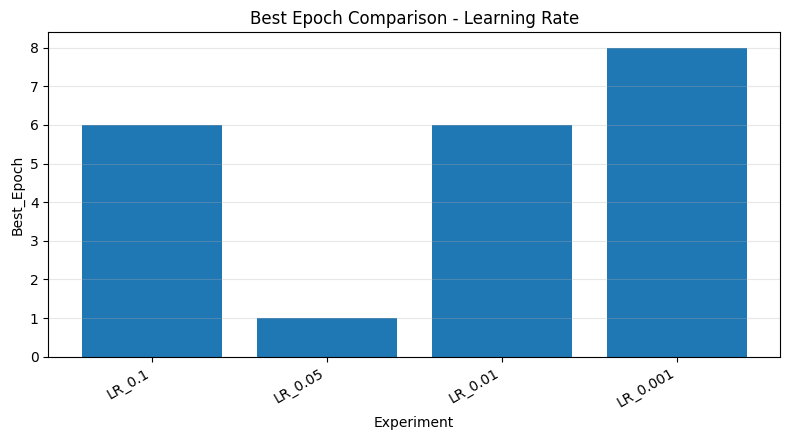

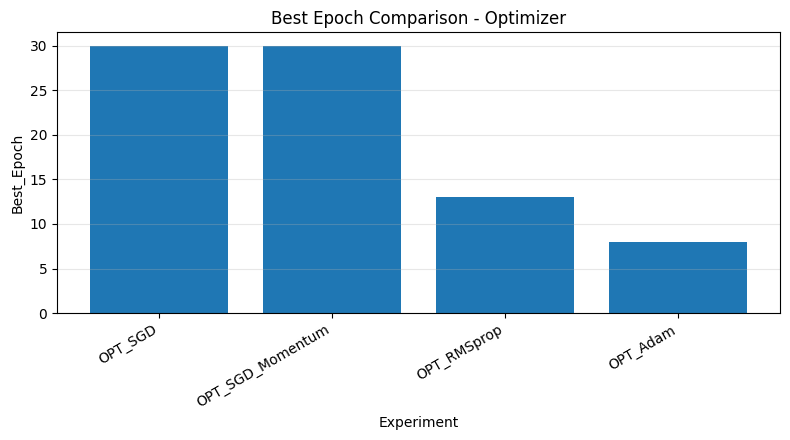

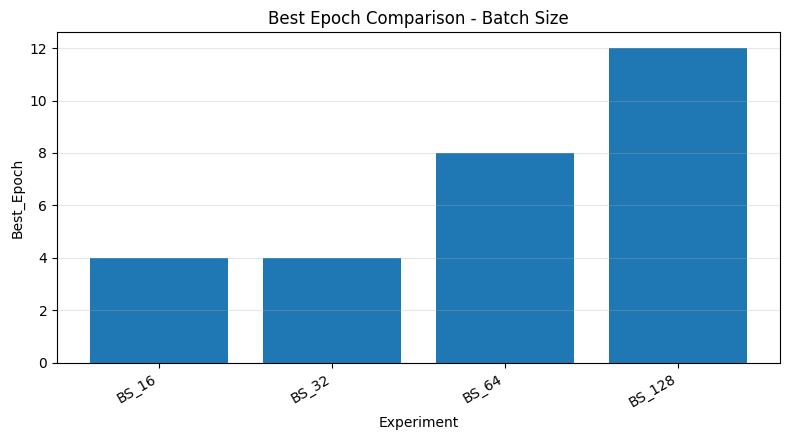

In [61]:
plot_metric_by_group(
    results_summary_df,
    metric="Best_Epoch",
    title="Best Epoch Comparison"
)

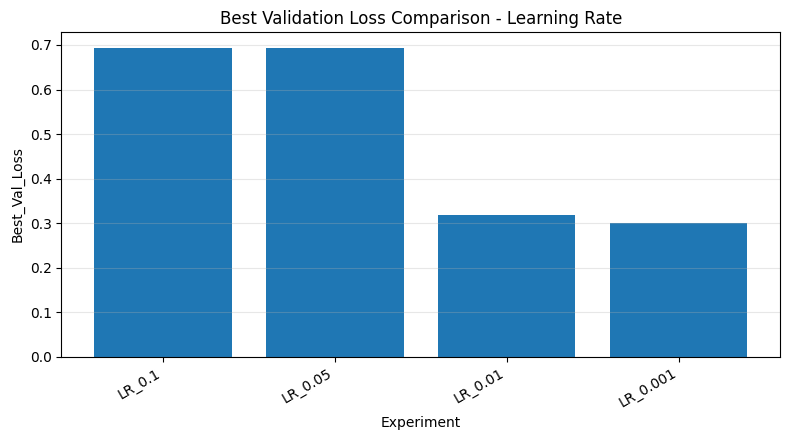

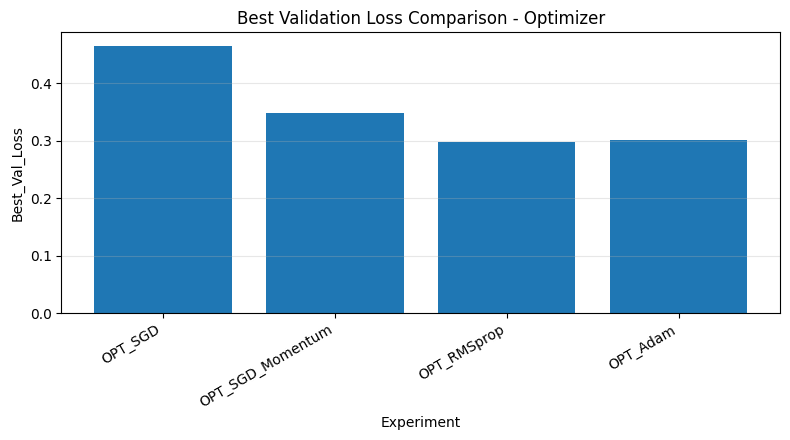

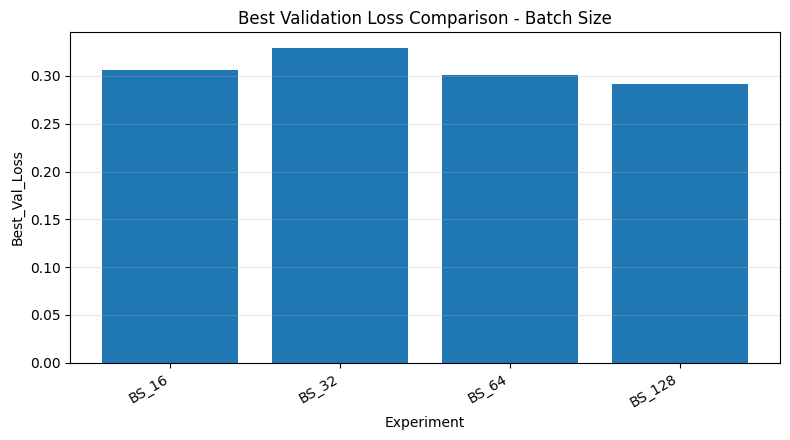

In [62]:
plot_metric_by_group(
    results_summary_df,
    metric="Best_Val_Loss",
    title="Best Validation Loss Comparison"
)

In [63]:
internal_summary_rows = []

for experiment_name, result in experiment_results.items():
    weight_df = result["weight_layer_stats"]

    for layer_name in weight_df["layer"].unique():
        layer_df = weight_df[weight_df["layer"] == layer_name]

        internal_summary_rows.append({
            "Experiment": experiment_name,
            "Layer": layer_name,
            "Mean_MeanAbsDelta": layer_df["mean_abs_delta"].mean(),
            "Mean_SumAbsDelta": layer_df["sum_abs_delta"].mean(),
            "Mean_MedianAbsDelta": layer_df["median_abs_delta"].mean(),
            "Max_MaxAbsDelta": layer_df["max_abs_delta"].max()
        })

internal_summary_df = pd.DataFrame(internal_summary_rows)

internal_summary_df[
    [
        "Experiment",
        "Layer",
        "Mean_MeanAbsDelta",
        "Mean_SumAbsDelta",
        "Mean_MedianAbsDelta",
        "Max_MaxAbsDelta"
    ]
].round(6)

,Experiment,Layer,Mean_MeanAbsDelta,Mean_SumAbsDelta,Mean_MedianAbsDelta,Max_MaxAbsDelta
0,LR_0.1,conv_1/kernel,0.051887,14.943465,0.053488,0.842152
1,LR_0.1,conv_2/kernel,0.046141,850.470886,0.051057,1.029848
2,LR_0.1,dense_hidden/kernel,0.035714,3657.159424,0.044516,1.239205
3,LR_0.1,output/kernel,0.042296,2.706921,0.042678,0.818522
4,LR_0.05,conv_1/kernel,0.046834,13.488238,0.049869,0.601467
5,LR_0.05,conv_2/kernel,0.041522,765.341553,0.045847,0.589503
6,LR_0.05,dense_hidden/kernel,0.032409,3318.635986,0.040405,0.551006
7,LR_0.05,output/kernel,0.038049,2.435130,0.038070,0.327980
8,LR_0.01,conv_1/kernel,0.027254,7.849086,0.008425,0.439815
9,LR_0.01,conv_2/kernel,0.014023,258.479553,0.005120,0.665138


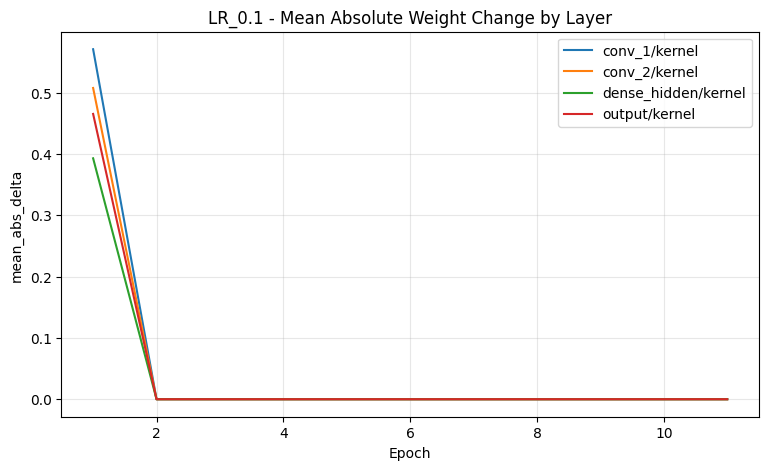

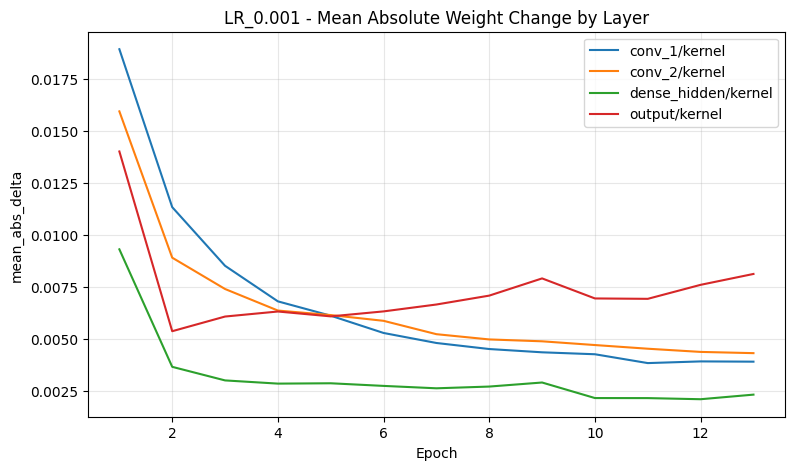

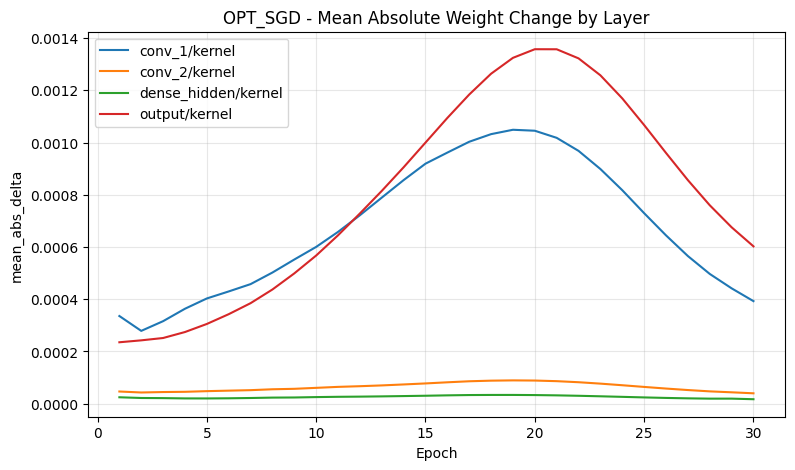

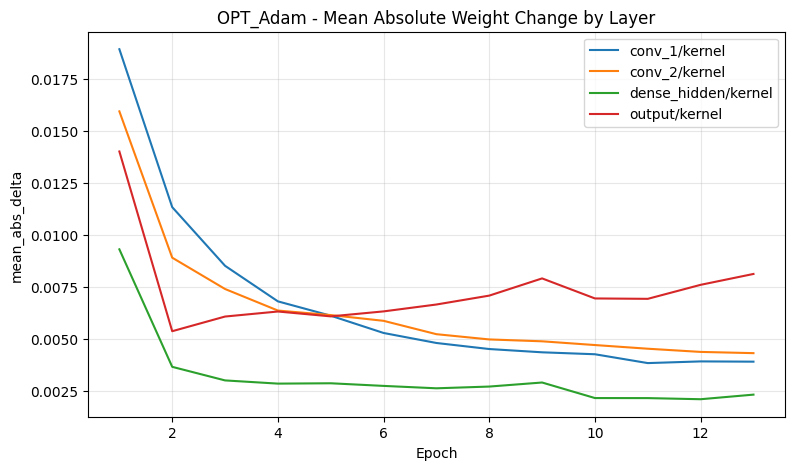

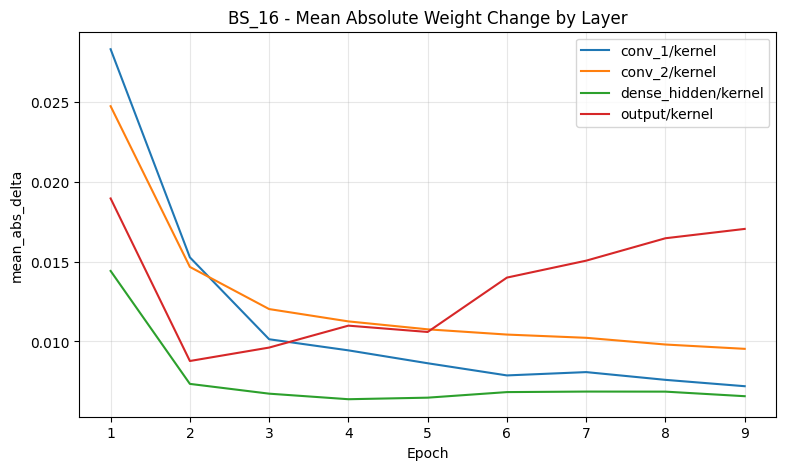

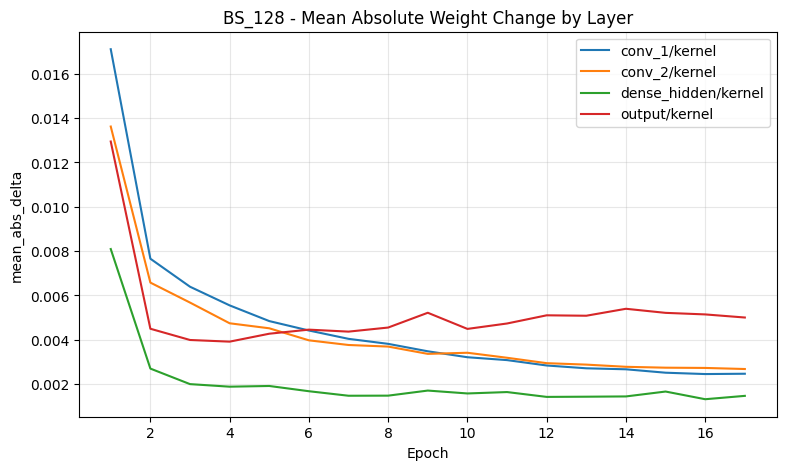

In [64]:
selected_internal_experiments = [
    "LR_0.1",
    "LR_0.001",
    "OPT_SGD",
    "OPT_Adam",
    "BS_16",
    "BS_128"
]

for experiment_name in selected_internal_experiments:
    if experiment_name in experiment_results:
        plot_weight_change_by_layer(
            experiment_results[experiment_name]["weight_layer_stats"],
            value_column="mean_abs_delta",
            title=f"{experiment_name} - Mean Absolute Weight Change by Layer"
        )

In [65]:
most_volatile_rows = []

for experiment_name, result in experiment_results.items():
    top_df = result["top_weight_changes"]

    max_row = top_df.loc[top_df["abs_delta"].idxmax()]

    most_volatile_rows.append({
        "Experiment": experiment_name,
        "Layer": max_row["layer"],
        "Epoch": max_row["epoch"],
        "Weight_Index": max_row["weight_index"],
        "Max_Abs_Delta": max_row["abs_delta"],
        "Delta": max_row["delta"]
    })

most_volatile_df = pd.DataFrame(most_volatile_rows)
most_volatile_df["Max_Abs_Delta"] = most_volatile_df["Max_Abs_Delta"].astype(float).round(6)
most_volatile_df["Delta"] = most_volatile_df["Delta"].astype(float).round(6)

most_volatile_df

,Experiment,Layer,Epoch,Weight_Index,Max_Abs_Delta,Delta
0,LR_0.1,dense_hidden/kernel,1,"(10, 14)",1.239205,1.239205
1,LR_0.05,conv_1/kernel,1,"(0, 2, 0, 11)",0.601467,-0.601467
2,LR_0.01,dense_hidden/kernel,11,"(1591, 31)",1.288569,-1.288569
3,LR_0.001,conv_2/kernel,1,"(1, 1, 14, 56)",0.128639,0.128639
4,OPT_SGD,output/kernel,20,"(24, 0)",0.005354,-0.005354
5,OPT_SGD_Momentum,output/kernel,3,"(24, 0)",0.041849,-0.041849
6,OPT_RMSprop,conv_2/kernel,1,"(2, 2, 19, 21)",0.098711,0.098711
7,OPT_Adam,conv_2/kernel,1,"(1, 1, 14, 56)",0.128639,0.128639
8,BS_16,conv_2/kernel,1,"(1, 2, 14, 39)",0.199546,0.199546
9,BS_32,conv_2/kernel,1,"(0, 1, 20, 2)",0.171757,-0.171757


In [67]:
top3_repetition_rows = []

for experiment_name, result in experiment_results.items():
    top_df = result["top_weight_changes"].copy()

    top_df["weight_id"] = (
        top_df["layer"].astype(str)
        + " | "
        + top_df["weight_index"].astype(str)
    )

    repetition_counts = (
        top_df
        .groupby("weight_id")
        .size()
        .sort_values(ascending=False)
    )

    most_repeated_weight = repetition_counts.index[0]
    repeat_count = repetition_counts.iloc[0]

    epochs_trained = result["summary"]["Epochs_Trained"]

    top3_repetition_rows.append({
        "Experiment": experiment_name,
        "Most_Repeated_Top3_Weight": most_repeated_weight,
        "Top3_Appearances": repeat_count,
        "Epochs_Trained": epochs_trained,
        "Appeared_In_All_Epochs": repeat_count == epochs_trained
    })

top3_repetition_df = pd.DataFrame(top3_repetition_rows)
top3_repetition_df

,Experiment,Most_Repeated_Top3_Weight,Top3_Appearances,Epochs_Trained,Appeared_In_All_Epochs
0,LR_0.1,"conv_1/kernel | (np.int64(2), np.int64(2), np....",10,11,False
1,LR_0.05,"output/kernel | (np.int64(32), np.int64(0))",5,6,False
2,LR_0.01,"conv_1/kernel | (np.int64(0), np.int64(1), np....",6,11,False
3,LR_0.001,"conv_1/kernel | (np.int64(1), np.int64(0), np....",12,13,False
4,OPT_SGD,"dense_hidden/kernel | (np.int64(980), np.int64...",26,30,False
5,OPT_SGD_Momentum,"conv_1/kernel | (np.int64(1), np.int64(1), np....",28,30,False
6,OPT_RMSprop,"output/kernel | (np.int64(44), np.int64(0))",17,18,False
7,OPT_Adam,"conv_1/kernel | (np.int64(1), np.int64(0), np....",12,13,False
8,BS_16,"conv_1/kernel | (np.int64(0), np.int64(2), np....",8,9,False
9,BS_32,"conv_1/kernel | (np.int64(2), np.int64(0), np....",8,9,False
